# 1. Imports y lectura del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import gc
import json
from eda_nan import plot_na_values, plot_na_values_multiple, plot_na_distributions

In [2]:
import os
import sys

parent_dir = os.path.abspath("..")
sys.path.append(parent_dir)

In [3]:
sns.set_theme(style="whitegrid", context="notebook")

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [5]:
df = pd.read_parquet('../datasets/parquet/AEMET_1970-01-01_2024-12-31.parquet')

s_df = pd.read_csv('../datasets/csv/AEMET_stations.csv')

df['provincia'] = (
    df['provincia']
    .astype(str)
    .replace({
        'STA. CRUZ DE TENERIFE': 'SANTA CRUZ DE TENERIFE',
        'ILLES BALEARS': 'BALEARES'
    })
    .astype('category')
)

In [6]:
# s_df[s_df['fecha_min'].isna()]

In [7]:
clm_provinces = ["ALBACETE", "CUENCA", "CIUDAD REAL", "GUADALAJARA", "TOLEDO"]
df_clm = df.loc[df['provincia'].isin(clm_provinces)].copy()
s_df_clm = s_df.loc[s_df['provincia'].isin(clm_provinces)].copy()

In [8]:
print('España:')
print(f'{df.shape[0]} registros de {df['indicativo'].nunique()} estaciones')
print('Castilla-La Mancha:')
print(f'{df_clm.shape[0]} registros de {df_clm['indicativo'].nunique()} estaciones')

España:
7427530 registros de 946 estaciones
Castilla-La Mancha:
489758 registros de 65 estaciones


# 2. Dataset general

## 2.1. Valores perdidos

In [9]:
(df.isna().sum() / df.shape[0]).sort_values(ascending=False)

sol                  0.722104
horaPresMax          0.712361
horaPresMin          0.699457
presMin              0.658454
presMax              0.658087
horaHrMax            0.592070
horaHrMin            0.431394
hrMax                0.346137
hrMin                0.346083
horaracha            0.312884
dir                  0.311548
racha                0.268755
velmedia             0.239498
horatmin             0.189172
hrMedia              0.169469
horatmax             0.149965
tmed                 0.049335
tmin                 0.048727
tmax                 0.048689
prec                 0.047252
latitud              0.013958
longitud             0.013958
nombre               0.000000
provincia            0.000000
fecha                0.000000
indicativo           0.000000
horaHrMinVarias      0.000000
dirVarias            0.000000
horatmaxVarias       0.000000
horaHrMaxVarias      0.000000
horatminVarias       0.000000
precAcum             0.000000
horaPresMaxVarias    0.000000
precIp    

### 2.1.1. España

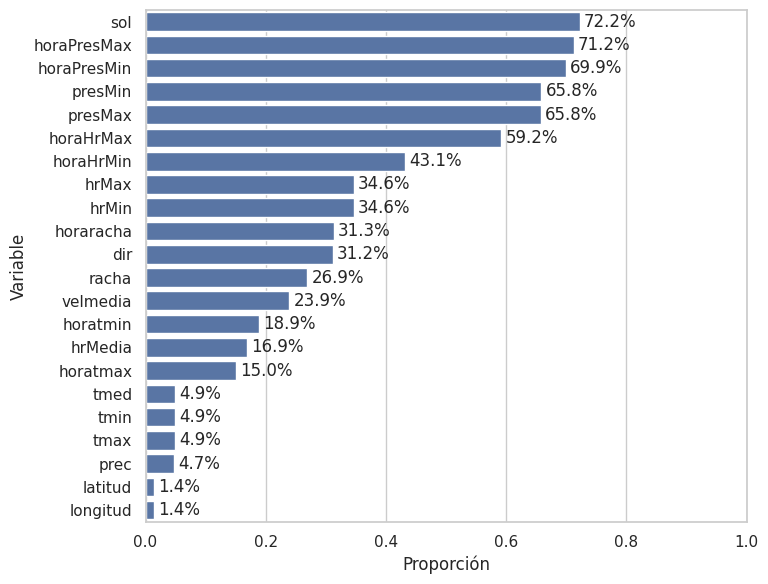

In [10]:
plot_na_values(
    df, fsize=(8, 6),
    # title='Proporción de valores perdidos por variable - España',
    title='',
)

### 2.2.2. Castilla-La Mancha

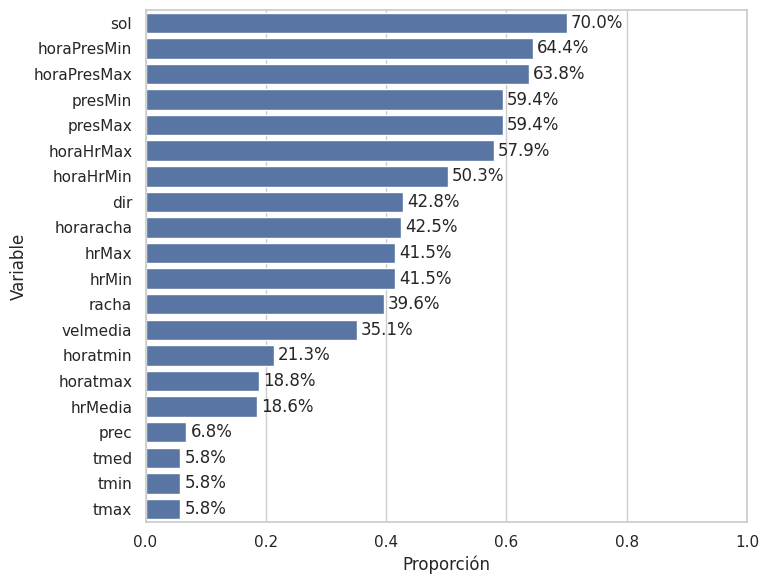

In [11]:
plot_na_values(
    df_clm, fsize=(8,6),
    # title='Proporción de valores perdidos por variable - Castilla-La Mancha',
    title='',
)

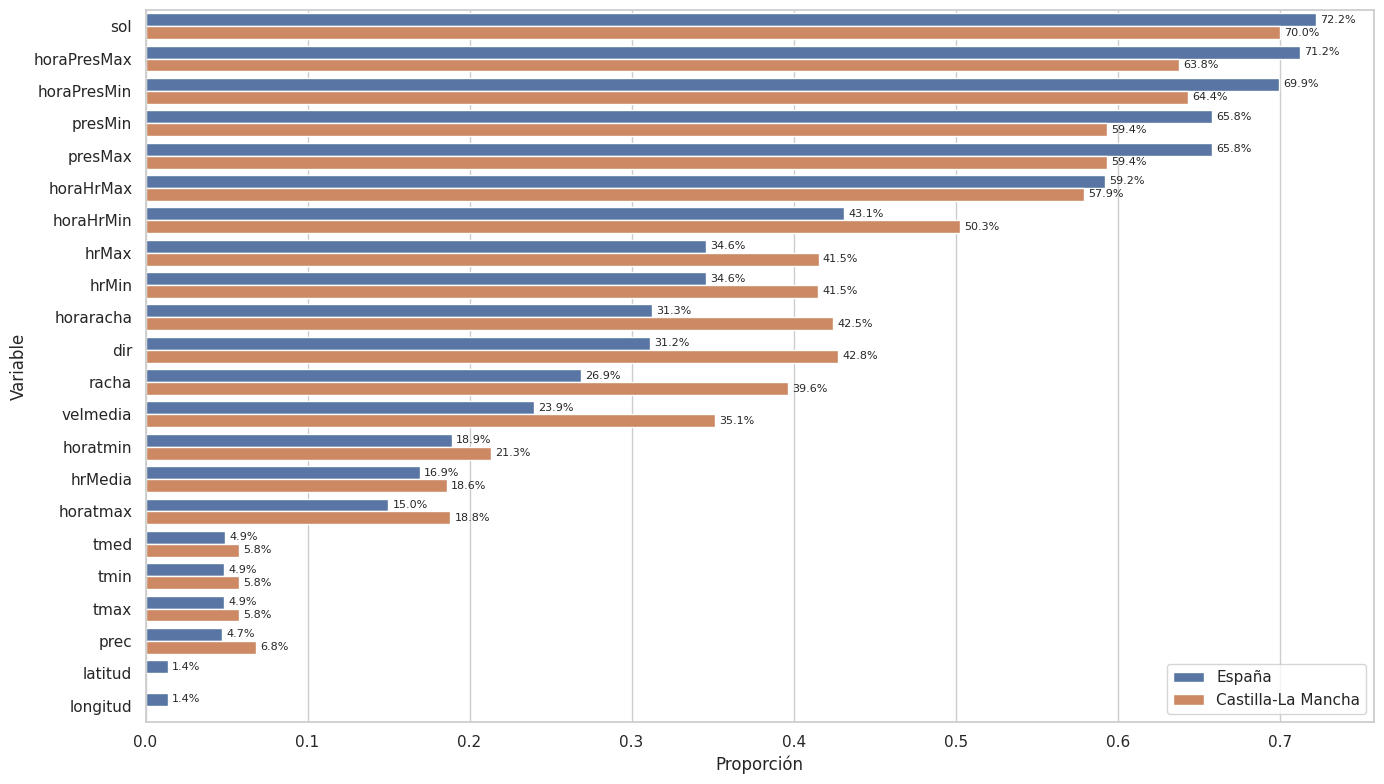

In [12]:
plot_na_values_multiple(
    df, df_clm,
    dataset_names=['España', 'Castilla-La Mancha'],
    fsize=(14, 8),
    title='',
    legend_title='',
    # dodge=False,
    # horizontal=False
)

## 2.3. Distribución de los datos

### 2.3.1. España

#### 2.3.1.1. Registros por provincia

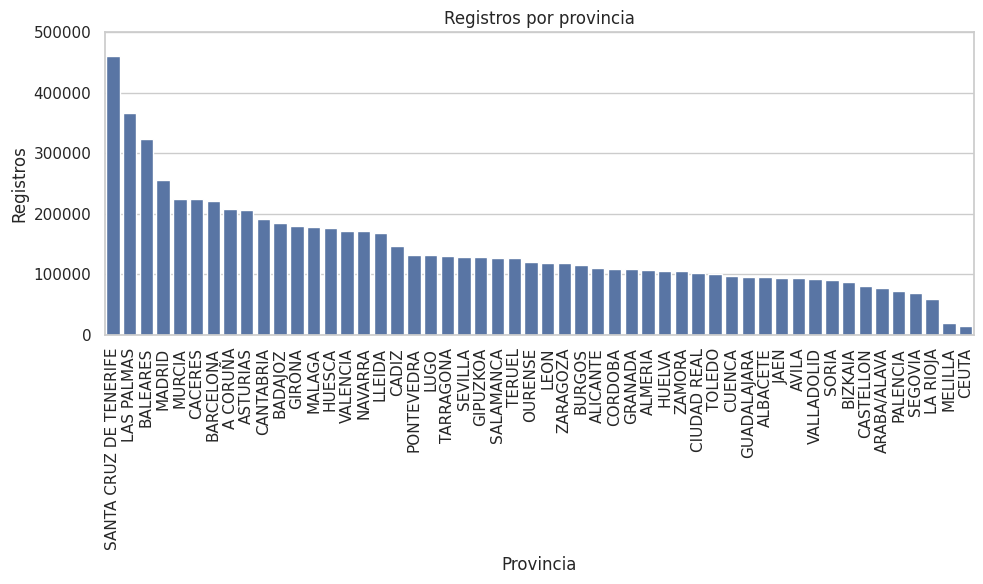

In [13]:
plt.figure(figsize=(10,6))
order = df['provincia'].value_counts().index
ax = sns.countplot(data=df, x='provincia', order=order)
plt.title('Registros por provincia')
plt.ylabel('Registros')
plt.xlabel('Provincia')

plt.ylim(0, 500_000)
plt.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

#### 2.3.1.2. Registros por año

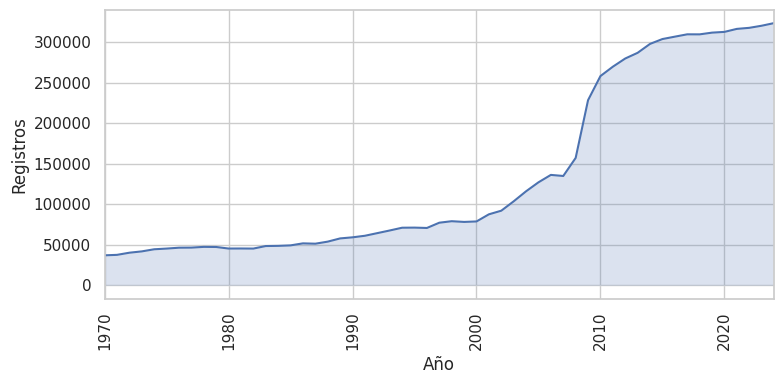

In [14]:
plt.figure(figsize=(8, 4))

daily_counts = df['anio'].value_counts().sort_index()
sns.lineplot(x=daily_counts.index, y=daily_counts.values)
plt.fill_between(daily_counts.index, daily_counts.values, alpha=0.2)

# plt.title('Registros por año')
plt.ylabel('Registros')
plt.xlabel('Año')


plt.xlim(1970, 2024)
plt.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

#### 2.3.1.3. Registros por día del año

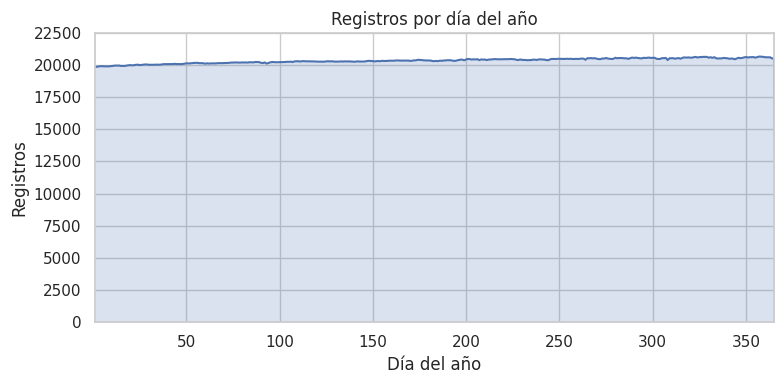

In [15]:
plt.figure(figsize=(8,4))

daily_counts = df['diaAnio'].value_counts().sort_index()
sns.lineplot(x=daily_counts.index, y=daily_counts.values)
plt.fill_between(daily_counts.index, daily_counts.values, alpha=0.2)

plt.title('Registros por día del año')
plt.ylabel('Registros')
plt.xlabel('Día del año')

plt.xlim(1,365)
plt.ylim(0, 22500)
plt.tight_layout()
plt.show()

#### 2.3.1.4. Distribución de año de registro

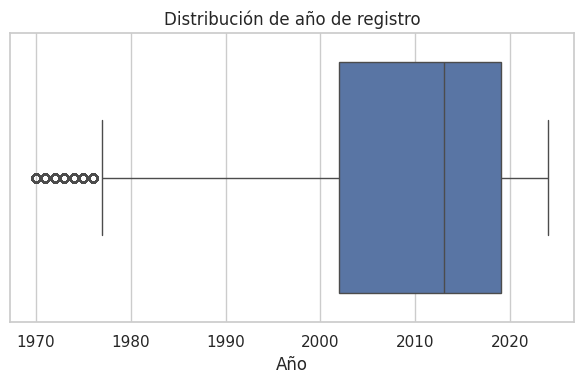

In [16]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x='anio')
plt.title('Distribución de año de registro')
plt.xlabel('Año')

plt.tight_layout()
plt.show()

#### 2.3.1.5 Distribución de altitud de estaciones

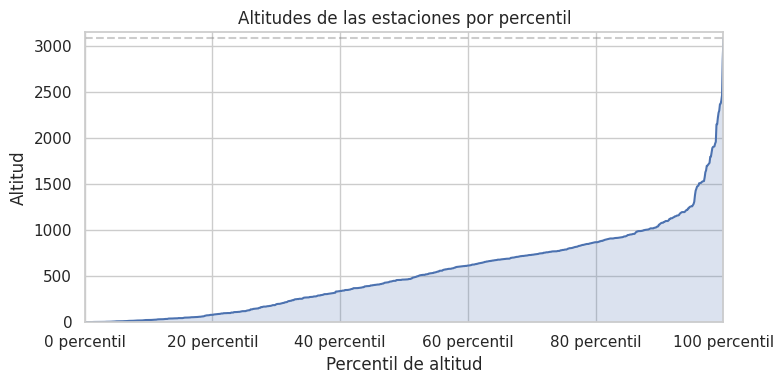

175

In [17]:
plt.figure(figsize=(8, 4))

s_sub = s_df.copy()
s_sub = s_sub.loc[
    (s_sub['altitud'].notna()),
    ['indicativo', 'altitud']
].sort_values(by='altitud').reset_index()

sns.lineplot(data=s_sub, x='indicativo', y='altitud')

plt.fill_between(s_sub['indicativo'], s_sub['altitud'], alpha=0.2)

plt.title('Altitudes de las estaciones por percentil')
plt.xlabel('Percentil de altitud')
plt.ylabel('Altitud')

x_max = s_sub.shape[0]-1
x_lines = [0, x_max//5, 2*x_max//5, 3*x_max//5, 4*x_max//5, x_max]
x_label = ['0 percentil', '20 percentil', '40 percentil', '60 percentil', '80 percentil', '100 percentil']

plt.axhline(y=s_sub['altitud'].max(), linestyle='--', alpha=0.4, color='grey')

plt.xticks(x_lines, x_label) 
plt.xlim(0, s_sub.shape[0]-1)
plt.ylim(0, 3150)
plt.tight_layout()
plt.show()

del s_sub
gc.collect()

### 2.3.2. Castilla-La Mancha

#### 2.3.2.1. Registros por provincia

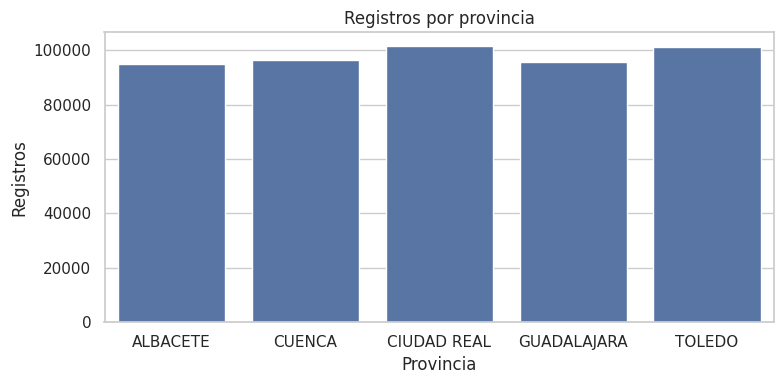

In [18]:
plt.figure(figsize=(8,4))

ax = sns.countplot(data=df_clm, x='provincia', order=clm_provinces)
plt.title('Registros por provincia')
plt.ylabel('Registros')
plt.xlabel('Provincia')

plt.tight_layout()
plt.show()

#### 2.3.2.2. Registros por año

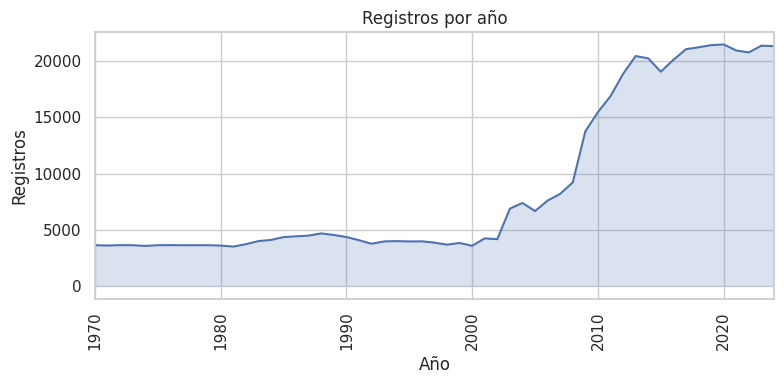

In [19]:
plt.figure(figsize=(8,4))

daily_counts = df_clm['anio'].value_counts().sort_index()
sns.lineplot(x=daily_counts.index, y=daily_counts.values)
plt.fill_between(daily_counts.index, daily_counts.values, alpha=0.2)
plt.title('Registros por año')
plt.ylabel('Registros')
plt.xlabel('Año')

plt.xlim(1970, 2024)
plt.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

#### 2.3.2.3. Comparación de proporcion de registros por año

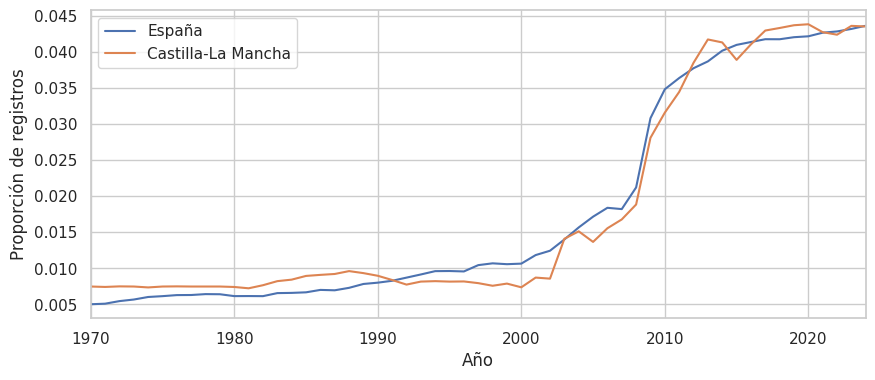

In [20]:
total = df.shape[0]
total_clm = df_clm.shape[0]
df_sub = (df.groupby('anio').size() / total).reset_index(name='registros')
df_sub['Conjunto de datos'] = 'España'
df_sub_clm = (df_clm.groupby('anio').size() / total_clm).reset_index(name='registros')
df_sub_clm['Conjunto de datos'] = 'Castilla-La Mancha'

df_sub = pd.concat([df_sub, df_sub_clm], ignore_index=True)

plt.figure(figsize=(10, 4))

sns.lineplot(data=df_sub, x='anio', y='registros', hue='Conjunto de datos')

plt.xlim(1970, 2024)
# plt.title('Proporción de registros por año')
plt.ylabel('Proporción de registros')
plt.xlabel('Año')
plt.legend()
# plt.tick_params(axis='x', rotation=90)
# plt.tight_layout()
plt.show()

#### 2.3.2.4. Registros por día del año

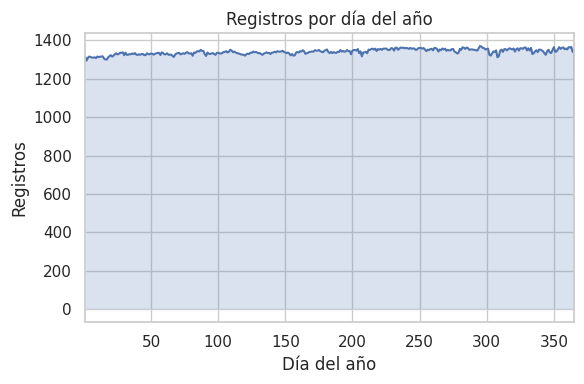

In [21]:
plt.figure(figsize=(6,4))
daily_counts = df_clm['diaAnio'].value_counts().sort_index()
sns.lineplot(x=daily_counts.index, y=daily_counts.values)
plt.fill_between(daily_counts.index, daily_counts.values, alpha=0.2)

plt.title('Registros por día del año')
plt.ylabel('Registros')
plt.xlabel('Día del año')

plt.xlim(1,365)
plt.tight_layout()
plt.show()

#### 2.3.2.5. Comparación de proporción de registros por día del año

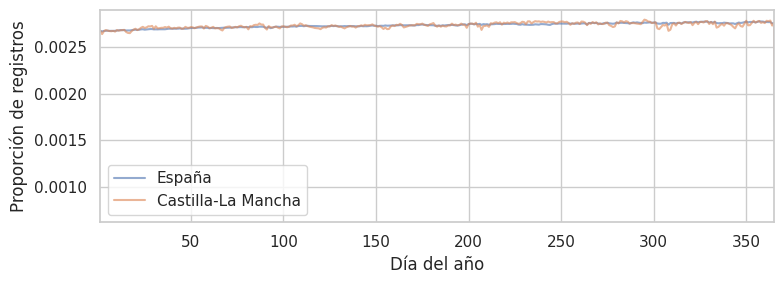

In [22]:
total = df.shape[0]
total_clm = df_clm.shape[0]
df_sub = (df.groupby('diaAnio').size() / total).reset_index(name='registros')
df_sub['dataset'] = 'España'
df_sub_clm = (df_clm.groupby('diaAnio').size() / total_clm).reset_index(name='registros')
df_sub_clm['dataset'] = 'Castilla-La Mancha'
df_sub = pd.concat([df_sub, df_sub_clm], ignore_index=True)

plt.figure(figsize=(8, 3))
sns.lineplot(data=df_sub, x='diaAnio', y='registros', hue='dataset', alpha=0.6)

plt.xlim(1, 365)
# plt.title('Proporción de registros por año')
plt.ylabel('Proporción de registros')
plt.xlabel('Día del año')
plt.legend()
# plt.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

#### 2.3.2.6. Distribución de año de registro

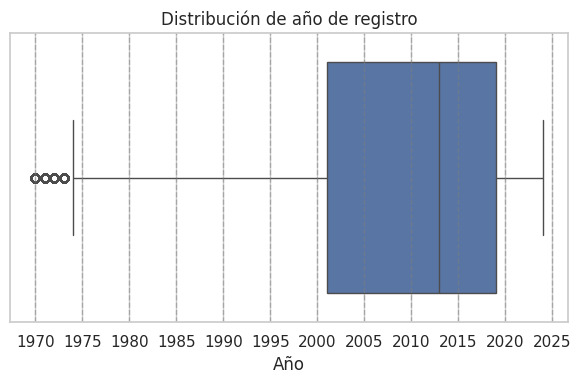

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clm, x='anio')
plt.title('Distribución de año de registro')
plt.xlabel('Año')

x_lines = [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
x_labels = [str(i) for i in x_lines]
for x_val in x_lines:
    plt.axvline(x=x_val, linestyle='--', alpha=0.5, linewidth=1, color='grey')

plt.xticks(x_lines, x_labels)
plt.tight_layout()
plt.show()

#### 2.3.2.7. Distribución de altitud de las estaciones

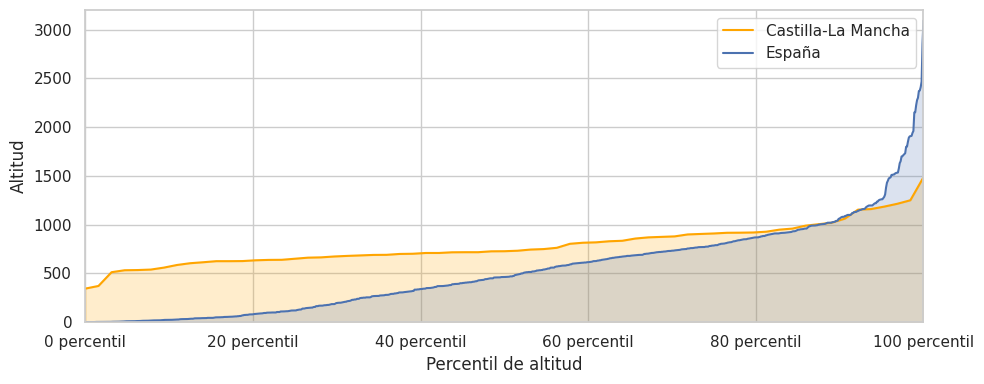

108678

In [24]:
plt.figure(figsize=(10, 4))

s_sub = s_df_clm.copy()
s_sub = s_sub.loc[
    (s_sub['altitud'].notna()),
    ['indicativo', 'altitud']
].sort_values(by='altitud').reset_index()
s_sub['percentile'] = np.linspace(0, 100, len(s_sub))

sns.lineplot(data=s_sub, x='percentile', y='altitud', color='orange', label='Castilla-La Mancha')
plt.fill_between(s_sub['percentile'], s_sub['altitud'], alpha=0.2, color='orange')

s_sub = s_df.copy()
s_sub = s_sub.loc[
    (s_sub['altitud'].notna()),
    ['indicativo', 'altitud']
].sort_values(by='altitud').reset_index()
s_sub['percentile'] = np.linspace(0, 100, len(s_sub))

sns.lineplot(data=s_sub, x='percentile', y='altitud',  label='España')

plt.fill_between(s_sub['percentile'], s_sub['altitud'], alpha=0.2)

# plt.title('Altitudes de las estaciones por percentil de altitud')
plt.xlabel('Percentil de altitud')
plt.ylabel('Altitud')
y_lines = [i*500 for i in range(7)]
y_label = [str(i*500) for i in range(7)]

x_max = s_sub.shape[0]-1
x_lines = [0, 20, 40, 60, 80, 100]
x_label = ['0 percentil', '20 percentil', '40 percentil', '60 percentil', '80 percentil', '100 percentil']

plt.xticks(x_lines, x_label)  
plt.yticks(y_lines, y_label)
plt.xlim(0, 100)
plt.ylim(0, 3200)
plt.tight_layout()
plt.show()

del s_sub
gc.collect()

## 2.4. Registros perdidos y rangos de series temporales

### 2.4.1. España

#### 2.4.1.1. Proporción de registros perdidos por estación

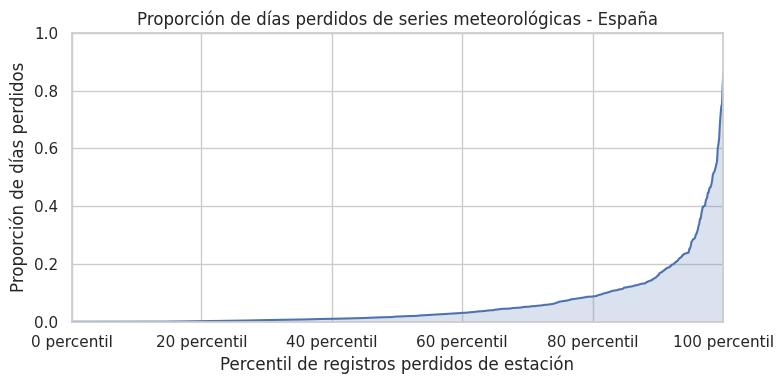

14510

In [25]:
plt.figure(figsize=(8, 4))

s_sub = s_df.copy()
s_sub = s_sub.loc[
    (s_sub['n_dias_teoricos']>0) & (s_sub['n_dias_teoricos'].notna())
].sort_values(by='proporcion_dias_perdidos').reset_index()

sns.lineplot(data=s_sub, x=s_sub.index, y='proporcion_dias_perdidos')

plt.fill_between(s_sub.index, s_sub['proporcion_dias_perdidos'], alpha=0.2)

plt.title('Proporción de días perdidos de series meteorológicas - España')
plt.xlabel('Percentil de registros perdidos de estación')
plt.ylabel('Proporción de días perdidos')

x_max = s_sub.shape[0]-1
x_ticks = [0, x_max//5, 2*x_max//5, 3*x_max//5, 4*x_max//5, x_max]
x_label = ['0 percentil', '20 percentil', '40 percentil', '60 percentil', '80 percentil', '100 percentil']

plt.xticks(x_ticks, x_label)
plt.xlim(0, s_sub.shape[0]-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

del s_sub
gc.collect()

#### 2.4.1.2. Distribución de primera y última fechas registradas

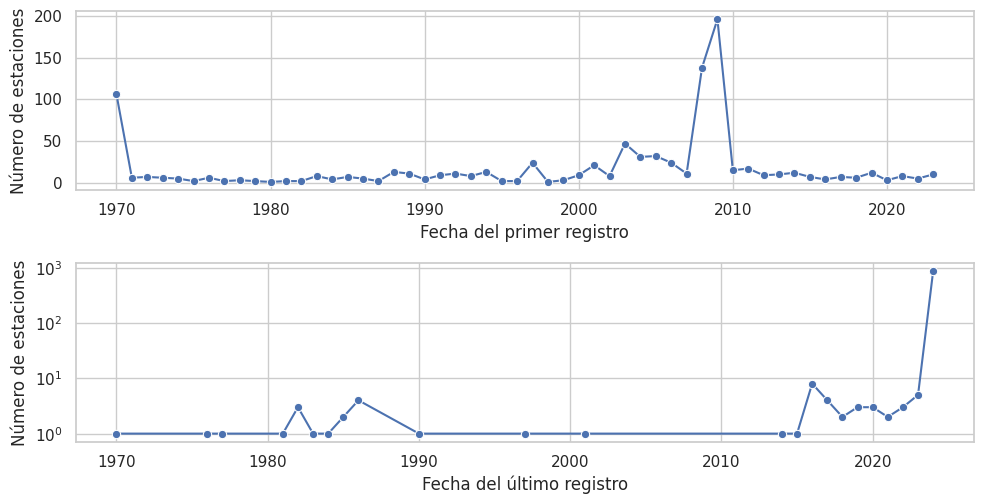

4718

In [26]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,5.2))

# ax1.set_title('Distribución de primera y última fecha registrada de estaciones - España')

s_sub = s_df[['indicativo', 'fecha_min', 'fecha_max']].copy()
s_sub['fecha_min'] = pd.to_datetime(s_sub['fecha_min']).dt.year
s_sub = s_sub.loc[s_sub['fecha_min'].notna()].groupby('fecha_min') \
    .size().reset_index(name='num').sort_values('fecha_min')

g = sns.lineplot(data=s_sub, x='fecha_min', y='num', marker='o', ax=ax1)
# g.set(yscale="log")
# ax1.set_title('Distribución de primera fecha registrada de estaciones - España')
# ax1.tick_params(rotation=90)
ax1.set_ylabel('Número de estaciones')
ax1.set_xlabel('Fecha del primer registro')

s_sub = s_df[['indicativo', 'fecha_min', 'fecha_max']].copy()
s_sub['fecha_max'] = pd.to_datetime(s_sub['fecha_max']).dt.year
s_sub = s_sub.loc[s_sub['fecha_max'].notna()].groupby('fecha_max') \
    .size().reset_index(name='num').sort_values('fecha_max')

g = sns.lineplot(data=s_sub, x='fecha_max', y='num', marker='o', ax=ax2)
g.set(yscale="log")
# ax2.set_title('Distribución de última fecha registrada de estaciones - España')
# ax2.tick_params(rotation=90)
ax2.set_ylabel('Número de estaciones')
ax2.set_xlabel('Fecha del último registro')

plt.ylabel('Número de estaciones')
plt.tight_layout()
plt.show()


del s_sub
gc.collect()

### 2.4.2. Castilla-La Mancha

#### 2.4.2.1. Proporción de registros perdidos por estación

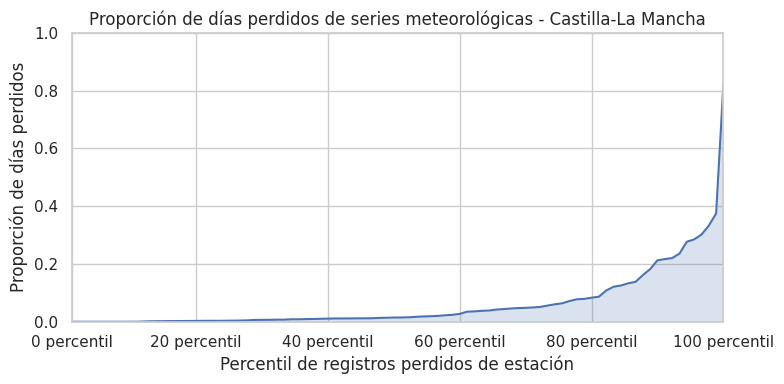

167

In [27]:
plt.figure(figsize=(8, 4))

s_sub = s_df.loc[df['provincia'].isin(clm_provinces)].copy()
s_sub = s_sub.loc[
    (s_sub['n_dias_teoricos']>0) & (s_sub['n_dias_teoricos'].notna())
].sort_values(by='proporcion_dias_perdidos').reset_index()

sns.lineplot(data=s_sub, x=s_sub.index, y='proporcion_dias_perdidos')

plt.fill_between(s_sub.index, s_sub['proporcion_dias_perdidos'], alpha=0.2)

plt.title('Proporción de días perdidos de series meteorológicas - Castilla-La Mancha')
plt.xlabel('Percentil de registros perdidos de estación')
plt.ylabel('Proporción de días perdidos')

x_max = s_sub.shape[0]-1
x_ticks = [0, x_max//5, 2*x_max//5, 3*x_max//5, 4*x_max//5, x_max]
x_label = ['0 percentil', '20 percentil', '40 percentil', '60 percentil', '80 percentil', '100 percentil']

plt.xticks(x_ticks, x_label)
plt.xlim(0, s_sub.shape[0]-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

del s_sub
gc.collect()

#### 2.4.2.2. Distribución de primera y última fechas registradas

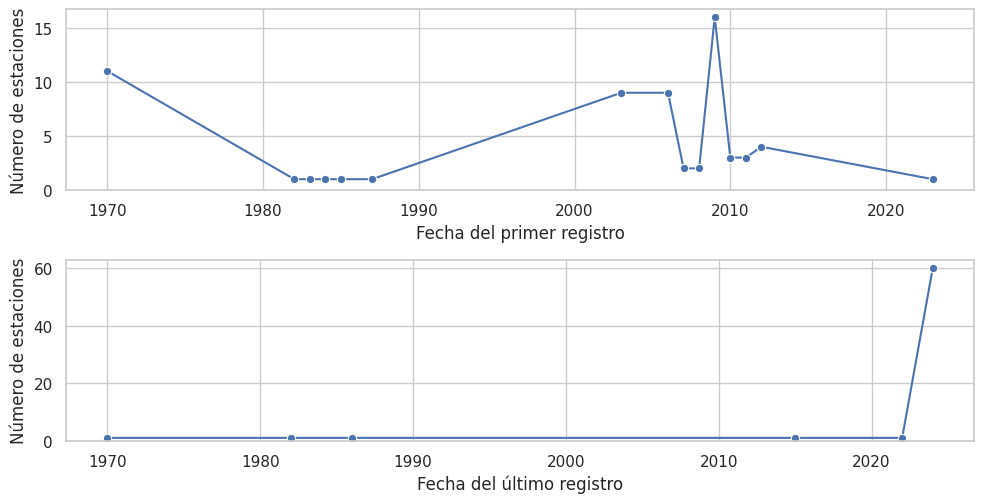

3004

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.2))

# Primera fecha registrada
s_sub = s_df_clm[['indicativo', 'fecha_min']].copy()
s_sub['fecha_min'] = pd.to_datetime(s_sub['fecha_min']).dt.year
s_sub = s_sub.loc[s_sub['fecha_min'].notna()].groupby('fecha_min') \
    .size().reset_index(name='num').sort_values('fecha_min')

sns.lineplot(data=s_sub, x='fecha_min', y='num', marker='o', ax=ax1)
# ax1.bar(s_sub['fecha_min'], s_sub['num'])
# ax1.set_title('Distribución de primera fecha registrada de estaciones - CLM')
ax1.set_ylabel('Número de estaciones')
ax1.set_xlabel('Fecha del primer registro')
# ax1.tick_params(rotation=90)
ax1.set_ylim(0, None)

# Última fecha registrada
s_sub = s_df_clm[['indicativo', 'fecha_max']].copy()
s_sub['fecha_max'] = pd.to_datetime(s_sub['fecha_max']).dt.year
s_sub = s_sub.loc[s_sub['fecha_max'].notna()].groupby('fecha_max') \
    .size().reset_index(name='num').sort_values('fecha_max')

sns.lineplot(data=s_sub, x='fecha_max', y='num', marker='o', ax=ax2)
# ax2.bar(s_sub['fecha_max'], s_sub['num'])
# ax2.set_title('Distribución de última fecha registrada - CLM')
ax2.set_ylabel('Número de estaciones')
ax2.set_xlabel('Fecha del último registro')
# ax2.tick_params(rotation=90)
ax2.set_ylim(0, None)

plt.tight_layout()
plt.show()
del s_sub
gc.collect()

# 3. Selección de estaciones

La selección se hará en base a los siguientes criterios:
> Fecha de inicio de registro menor o igual a `2010-01-01`.

> Fecha de final de registro mayor o igual a `2024-01-01`.

> Tiene registros de presión atmosférica: además de la relevancia de la presión atmosférica en el ámbito de la predicción meteorológica, se ha observado que el subconjunto de registros que sí tienen presión atmosférica tiene una proporción considerablemente menor de valores perdidos, salvo en los referentes a humedad relativa máxima y mínima, que de todas formas son dependientes de la temperatura, y cuya temperatura en el instante de ocurrencia no está registrada, se considera la humedad media como una mejor manera de conocer la cantidad de agua en el aire, quedando abierta la opción del cálculo de la humedad absoluta.

> Se establece un requisito de proporción de NaNs inferior o igual a `0.20` en las variables `tmax`, `tmed`, `tmin`, `velmedia`, `racha`, `hrMedia`, `prec`, `presMax`, `presMin`. 

> Tiene una proporción de registros perdidos inferior o igual a `0.01`.

> Altitud inferior o igual a 750 metros.

In [29]:
from dataset_processing import processor

In [30]:
df = pd.read_parquet('../datasets/parquet/AEMET_1970-01-01_2024-12-31.parquet')
s_df = pd.read_csv('../datasets/csv/AEMET_stations.csv')

In [31]:
df_selected, s_df_selected = processor.select_aemet_stations(df, s_df)

## 3.1. Análisis de threshold de días perdidos

### Código

In [32]:
def get_avg_missing_row_proportion(s):
    avg = s['proporcion_dias_perdidos'].sum() / s.shape[0]
    return avg

In [33]:
def get_avg_missing_val_proportion(df):
    avg = df.isna().mean().mean()
    return avg

In [34]:
def get_avg_year_coverage(df, s_df):
    return (df.shape[0] / s_df.shape[0]) / 365.25

In [35]:
avg_missing_row_proportion = get_avg_missing_row_proportion(s_df_selected)
print(avg_missing_row_proportion)

0.0007263229915216852


In [36]:
avg_missing_val_proportion = get_avg_missing_val_proportion(df_selected)
print(avg_missing_val_proportion)

0.0049868140886583645


In [37]:
avg_year_coverage = get_avg_year_coverage(df_selected, s_df_selected)
print(avg_year_coverage)

33.15860867400909


## 3.2. Distribución espacial

### Latitud y longitud

#### España

Antes de selección

In [38]:
s_df_aux = s_df[s_df['indicativo'].isin(df['indicativo'].unique())]

fig = px.scatter_map(s_df, lat='latitud', lon='longitud')

min_lat, max_lat = s_df['latitud'].min(), s_df['latitud'].max()
min_lon, max_lon = s_df['longitud'].min(), s_df['longitud'].max()

centro_lat = (min_lat + max_lat) / 2
centro_lon = (min_lon + max_lon) / 2

fig.update_traces(marker={"size": 5})

fig.update_layout(
    map_style='carto-positron-nolabels',
    map_center={"lat": centro_lat, "lon": centro_lon},
    map_zoom=4.7,
    margin={'l': 5, 'r': 5, 't': 5, 'b': 5}, 
    width=1400, 
    height=800
)

fig.show()

Después de selección

In [39]:
fig = px.scatter_map(s_df_selected, lat='latitud', lon='longitud')

min_lat, max_lat = s_df_selected['latitud'].min(), s_df_selected['latitud'].max()
min_lon, max_lon = s_df_selected['longitud'].min(), s_df_selected['longitud'].max()

centro_lat = (min_lat + max_lat) / 2
centro_lon = (min_lon + max_lon) / 2

fig.update_traces(marker={"size": 5})

fig.update_layout(
    map_style='carto-positron-nolabels',
    map_center={"lat": centro_lat, "lon": centro_lon},
    map_zoom=4.6,
    margin={'l': 5, 'r': 5, 't': 5, 'b': 5}, 
    width=1400, 
    height=800
)

fig.show()

#### Castilla-La Mancha

In [40]:
fig = px.scatter_map(s_df_clm, lat='latitud', lon='longitud', zoom=6)
fig.layout.map.style = 'carto-positron-nolabels'
fig.update_layout(margin={'l': 5, 'r': 5, 't': 5, 'b':5}, width=600, height=600)
fig.show()

In [41]:
fig = px.scatter_map(s_df_clm[s_df_clm['altitud'] <= 750], lat='latitud', lon='longitud', zoom=6)
fig.layout.map.style = 'carto-positron-nolabels'
fig.update_layout(margin={'l': 5, 'r': 5, 't': 5, 'b':5}, width=600, height=600)
fig.show()

In [42]:
fig = px.scatter_map(
    s_df_clm[s_df_clm['altitud'] > 750],
    lat='latitud', lon='longitud',
    color='altitud', zoom=6,
    color_continuous_scale='Turbo'
)
fig.layout.map.style = 'carto-positron-nolabels'
fig.update_layout(margin={'l': 5, 'r': 5, 't': 5, 'b':5}, width=600, height=600)
fig.show()

In [43]:
s_clm_aux = s_df_clm[s_df_clm['indicativo'].isin(df_clm['indicativo'].unique())]

s_clm_n = s_clm_aux.loc[s_clm_aux["latitud"] == s_clm_aux["latitud"].max()]
s_clm_s = s_clm_aux.loc[s_clm_aux["latitud"] == s_clm_aux["latitud"].min()]
s_clm_e = s_clm_aux.loc[s_clm_aux["longitud"] == s_clm_aux["longitud"].max()]
s_clm_w = s_clm_aux.loc[s_clm_aux["longitud"] == s_clm_aux["longitud"].min()]

print(f"Punto más al norte: {s_clm_n['nombre'].iloc[0]} \tLatitud: {s_clm_n['latitud'].iloc[0]}")
print(f"Punto más al sur: {s_clm_s['nombre'].iloc[0]} \tLatitud: {s_clm_s['latitud'].iloc[0]}")
print(f"Punto más al este: {s_clm_e['nombre'].iloc[0]} \tLongitud: {s_clm_e['longitud'].iloc[0]}")
print(f"Punto más al oeste: {s_clm_w['nombre'].iloc[0]} \tLongitud: {s_clm_w['longitud'].iloc[0]}")

Punto más al norte: SIGÜENZA 	Latitud: 41.08638888888889
Punto más al sur: NERPIO 	Latitud: 38.08833333333334
Punto más al este: ALMANSA 	Longitud: -1.0630555555555556
Punto más al oeste: OROPESA 	Longitud: -5.114444444444444


#### Countplot de provincias

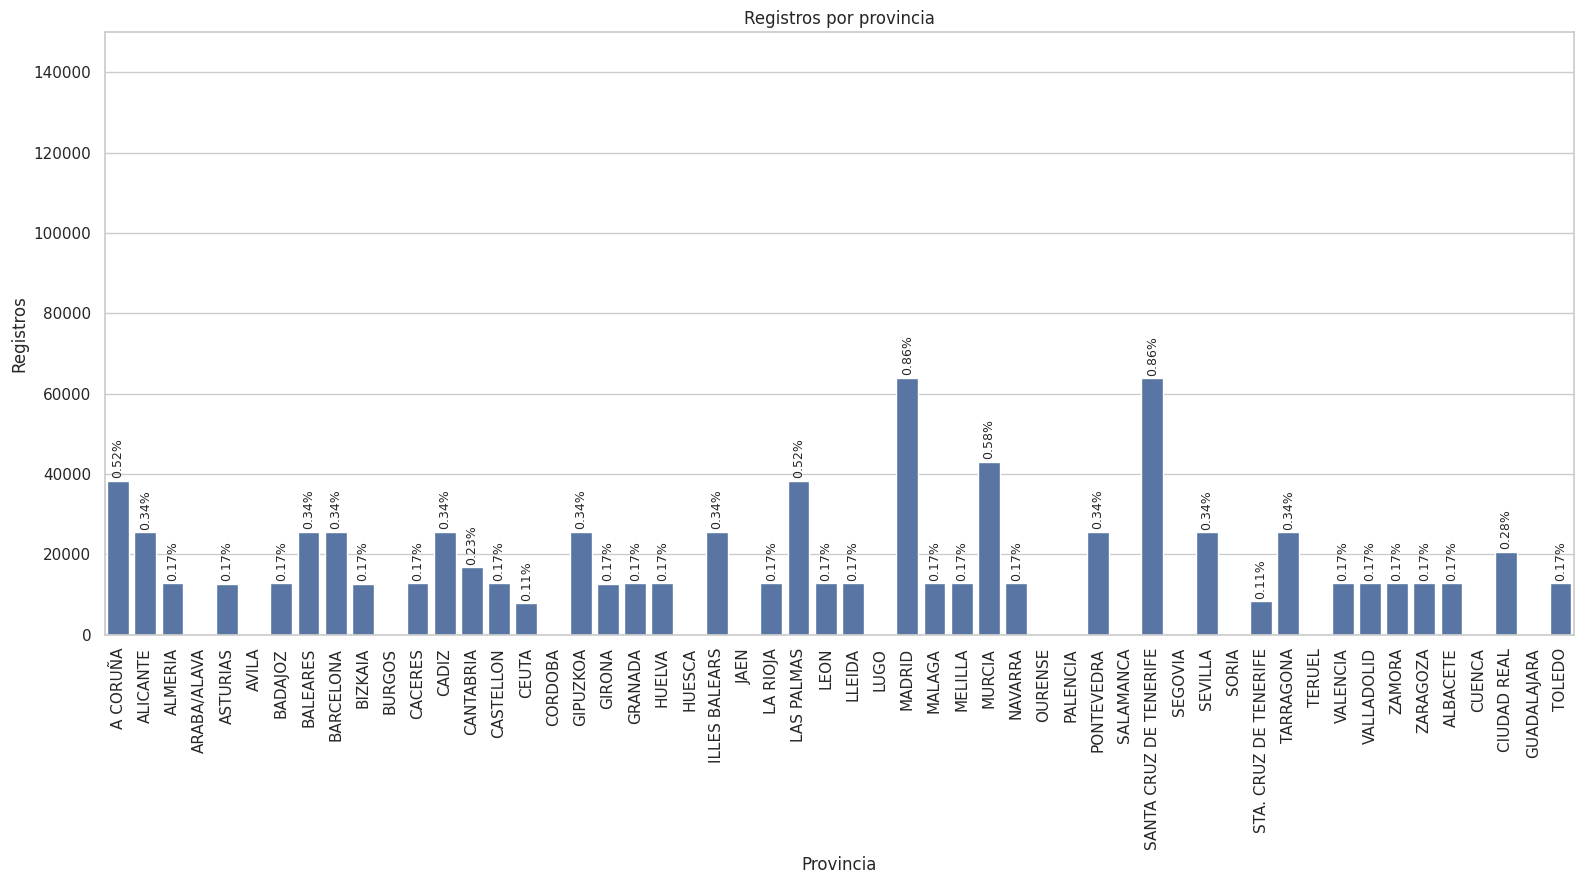

In [44]:
clm_provinces = ["ALBACETE", "CUENCA", "CIUDAD REAL", "GUADALAJARA", "TOLEDO"]
ordered_provinces = sorted(df[~df['provincia'].isin(clm_provinces)]['provincia'].unique())
ordered_provinces += clm_provinces

plt.figure(figsize=(16,9))

ax = sns.countplot(data=df_selected, x='provincia', order=ordered_provinces)
plt.title('Registros por provincia')
plt.ylabel('Registros')
plt.xlabel('Provincia')

total = len(df)
max_height = max(p.get_height() for p in ax.patches)
for p in ax.patches:
    height = p.get_height()
    proportion = height / total
    # Poner porcentaje de registros en coordenadas de columna
    ax.text(
        p.get_x() + p.get_width()/2, 
        height + (max_height * 0.01),
        f'{proportion:.2%}', 
        ha='center', 
        va='bottom', 
        fontsize=9,
        rotation=90
    )

# y_lines = [20_000 * i for i in range(8)]
# for y_val in y_lines:
#     plt.axhline(y=y_val, linestyle='--', alpha=0.4, linewidth=1, color='grey')

plt.ylim(0, 150_000)
plt.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## 3.3. Conteo de estaciones y registros

### España

In [45]:
print(f'Hay un total de {df_selected.shape[0]} de {s_df_selected.shape[0]} estaciones')
print(f'De las cuales {s_df_selected[s_df_selected['altitud'] > 750].shape[0]} tienen una altitud superior a 750m')

Hay un total de 799338 de 66 estaciones
De las cuales 0 tienen una altitud superior a 750m


### Castilla-La Mancha

In [46]:
print(f'Hay un total de {df_clm.shape[0]} de {s_df_clm.shape[0]} estaciones')
print(f'De las cuales {s_df_clm[s_df_clm['altitud'] > 750].shape[0]} tienen una altitud superior a 750m')

Hay un total de 489758 de 65 estaciones
De las cuales 29 tienen una altitud superior a 750m


# 4. Evaluación de selección

## 4.1. España

In [47]:
df_selected.head()

,fecha,indicativo,nombre,provincia,tmed,tmax,tmin,velmedia,racha,hrMedia,prec,presMax,presMin,anio,mes,dia,diaAnio,altitud,longitud,latitud
0,1990-01-01,0016A,REUS AEROPUERTO,TARRAGONA,9.0,12.6,5.4,0.6,5.0,89.0,0.0,1012.700012,1009.200012,1990,1,1,1,71,1.163611,41.145000
1,1990-01-01,0076,BARCELONA AEROPUERTO,BARCELONA,9.2,14.4,4.0,3.6,NaN,74.0,0.0,1018.099976,1016.599976,1990,1,1,1,4,2.070000,41.292778
2,1990-01-01,0200E,"BARCELONA, FABRA",BARCELONA,9.2,12.0,6.4,5.6,8.9,62.0,0.0,969.900024,968.200012,1990,1,1,1,408,2.124167,41.418335
3,1990-01-01,0367,GIRONA AEROPUERTO,GIRONA,7.0,15.0,-1.0,1.7,5.0,82.0,0.0,1003.900024,1001.799988,1990,1,1,1,143,2.763056,41.911388
4,1990-01-01,1014,"HONDARRIBIA, MALKARROA",GIPUZKOA,11.2,15.4,7.0,2.2,11.1,88.0,14.1,1020.599976,1014.700012,1990,1,1,1,4,-1.792222,43.356945


In [48]:
# list(df_selected.isna().sum())

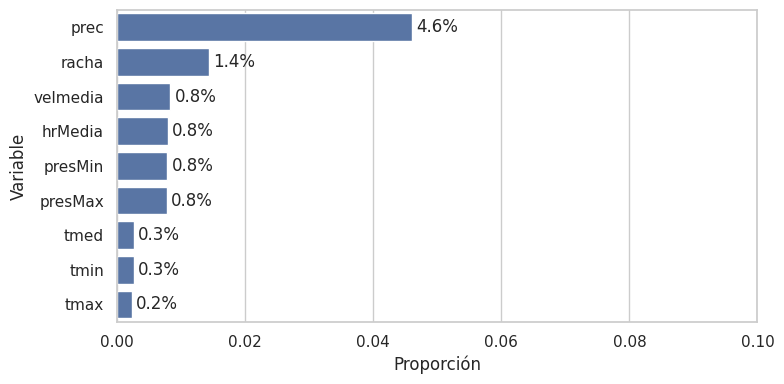

In [100]:
plot_na_values(df_selected, fsize=(8,4), orient='h', title='', xlim=(0, 0.1))

## 4.2. Castilla-La Mancha

In [50]:
from dataset_processing.config import COLS_TO_DROP

In [51]:
df_clm = df_clm.drop(columns=COLS_TO_DROP)
df_clm.head()

,fecha,indicativo,nombre,provincia,tmed,tmax,tmin,velmedia,racha,hrMedia,prec,presMax,presMin,anio,mes,dia,diaAnio,altitud,longitud,latitud
34,1970-01-01,3013,MOLINA DE ARAGÓN,GUADALAJARA,-2.4,2.4,-7.2,0.8,4.2,87.0,0.0,888.099976,878.700012,1970,1,1,1,1062,-1.878889,40.841667
35,1970-01-01,3103,PANTANO EL VADO,GUADALAJARA,2.4,3.2,1.6,NaN,NaN,NaN,6.8,NaN,NaN,1970,1,1,1,910,-3.301944,41.003613
37,1970-01-01,3168A,"GUADALAJARA, INSTITUTO",GUADALAJARA,4.5,7.0,2.0,0.6,NaN,90.0,0.0,931.299988,925.299988,1970,1,1,1,685,-3.166667,40.634724
42,1970-01-01,3259,"TOLEDO, LORENZANA",TOLEDO,5.8,9.0,2.6,1.4,10.8,79.0,0.0,947.599976,938.799988,1970,1,1,1,540,-4.025556,39.859444
43,1970-01-01,3365A,TALAVERA DE LA REINA,TOLEDO,5.5,11.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1970,1,1,1,372,-4.863611,39.958611


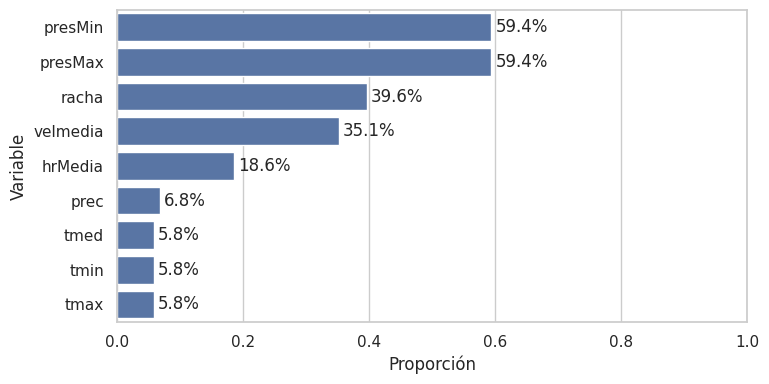

In [98]:
plot_na_values(df_clm, fsize=(8,4), orient='h', title='')

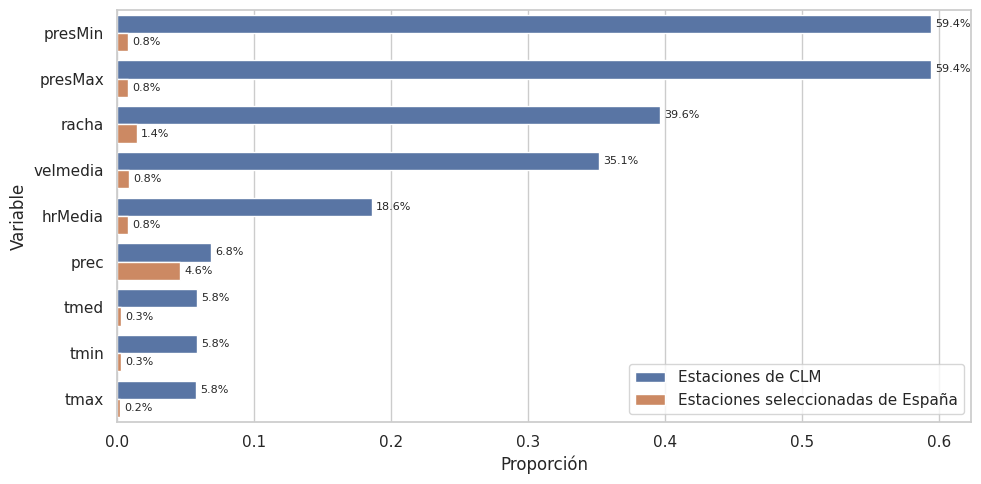

In [53]:
plot_na_values_multiple(df_clm, df_selected, dataset_names=['Estaciones de CLM', 'Estaciones seleccionadas de España'], fsize=(10,5), title='')

## Recordatorio

In [54]:
print(f'Hay un total de {s_df_selected.shape[0]} estaciones seleccionadas en toda España')
print(f'De las cuales {s_df_selected[s_df_selected['altitud'] > 750].shape[0]} tienen una altitud superior a 750m')
print()
print(f'Hay un total de {s_df_clm.shape[0]} estaciones seleccionadas en Castilla-La Mancha')
print(f'De las cuales {s_df_clm[s_df_clm['altitud'] > 750].shape[0]} tienen una altitud superior a 750m')

Hay un total de 66 estaciones seleccionadas en toda España
De las cuales 0 tienen una altitud superior a 750m

Hay un total de 65 estaciones seleccionadas en Castilla-La Mancha
De las cuales 29 tienen una altitud superior a 750m


# 5. Exploración de selección adicional

Se considerará aplicar un criterio adicional de filtrado de estaciones para el dataset de entrenamiento final. Serán analizados los valores NaNs por columna y por indicativo.

In [55]:
s_df = pd.read_csv('../datasets/csv/AEMET_stations.csv')
df = pd.read_parquet('../datasets/parquet/AEMET_1970-01-01_2024-12-31.parquet')

In [56]:
selected_stations = s_df.loc[
    (s_df['proporcion_dias_perdidos'] <= 0.01)
    # (s_df['fecha_min'] <= '2010-01-01')
    
    & (s_df['fecha_min'] <= '2010-01-01')
    & (s_df['fecha_max'] >= '2024-01-01')
    # & (s_df['altitud'] <= 750)
] 
selected_stations

,latitud,provincia,altitud,indicativo,nombre,indsinop,longitud,n_dias_reales,n_dias_teoricos,n_dias_perdidos,fecha_min,fecha_max,proporcion_dias_perdidos,nan_fecha,nan_indicativo,nan_nombre,nan_provincia,nan_tmed,nan_tmax,nan_tmin,nan_horatmax,nan_horatmin,nan_horatmaxVarias,nan_horatminVarias,nan_velmedia,nan_racha,nan_horaracha,nan_dir,nan_dirVarias,nan_hrMedia,nan_hrMax,nan_hrMin,nan_horaHrMax,nan_horaHrMin,nan_horaHrMaxVarias,nan_horaHrMinVarias,nan_prec,nan_precIp,nan_precAcum,nan_sol,nan_presMax,nan_presMin,nan_horaPresMax,nan_horaPresMin,nan_horaPresMaxVarias,nan_horaPresMinVarias,nan_anio,nan_mes,nan_dia,nan_diaAnio,nan_altitud,nan_longitud,nan_latitud
2,39.689167,ILLES BALEARS,60,B087X,BANYALBUFAR,NaN,2.512778,5896.0,5905.0,9.0,2008-11-01,2024-12-31,0.001524,0.0,0.0,0.0,0.0,75.0,75.0,75.0,291.0,618.0,0.0,0.0,3061.0,3075.0,3212.0,3239.0,0.0,14.0,88.0,88.0,1487.0,654.0,0.0,0.0,26.0,0.0,0.0,5896.0,5896.0,5896.0,5896.0,5896.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,39.551389,BALEARES,50,B158X,"CALVIÀ, ES CAPDELLÀ",NaN,2.466389,5860.0,5905.0,45.0,2008-11-01,2024-12-31,0.007621,0.0,0.0,0.0,0.0,54.0,54.0,54.0,135.0,321.0,0.0,0.0,37.0,72.0,449.0,544.0,0.0,56.0,101.0,101.0,1968.0,658.0,0.0,0.0,51.0,0.0,0.0,5860.0,5860.0,5860.0,5860.0,5860.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,39.554167,BALEARES,3,B228,"PALMA, PUERTO",8301.0,2.625278,17167.0,17167.0,0.0,1978-01-01,2024-12-31,0.000000,0.0,0.0,0.0,0.0,16.0,13.0,16.0,341.0,705.0,0.0,0.0,99.0,42.0,473.0,347.0,0.0,51.0,10315.0,10318.0,12449.0,10828.0,0.0,0.0,848.0,0.0,0.0,79.0,297.0,297.0,1013.0,1377.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,39.642222,ILLES BALEARS,95,B236C,"PALMA, UNIVERSITAT",NaN,2.643889,5897.0,5905.0,8.0,2008-11-01,2024-12-31,0.001355,0.0,0.0,0.0,0.0,98.0,98.0,98.0,187.0,454.0,0.0,0.0,24.0,75.0,403.0,473.0,0.0,35.0,134.0,134.0,2388.0,684.0,0.0,0.0,27.0,0.0,0.0,5897.0,5897.0,5897.0,5897.0,5897.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,39.560833,BALEARES,5,B278,"PALMA DE MALLORCA, AEROPUERTO",8306.0,2.736667,19146.0,19146.0,0.0,1972-08-01,2024-12-31,0.000000,0.0,0.0,0.0,0.0,566.0,565.0,565.0,852.0,879.0,0.0,0.0,688.0,1066.0,1357.0,1204.0,0.0,610.0,12597.0,12598.0,13959.0,12752.0,0.0,0.0,1350.0,0.0,0.0,20.0,559.0,559.0,1285.0,1343.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,41.524722,HUESCA,170,9924X,FRAGA,NaN,0.355556,5644.0,5663.0,19.0,2009-07-01,2024-12-31,0.003355,0.0,0.0,0.0,0.0,15.0,14.0,14.0,174.0,514.0,0.0,0.0,146.0,154.0,368.0,436.0,0.0,5.0,18.0,18.0,1450.0,871.0,0.0,0.0,27.0,0.0,0.0,5644.0,5644.0,5644.0,5644.0,5644.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
910,41.177222,TARRAGONA,370,9947X,LA POBLA DE MASSALUCA,NaN,0.353333,5600.0,5627.0,27.0,2009-08-06,2024-12-31,0.004798,0.0,0.0,0.0,0.0,59.0,59.0,59.0,196.0,588.0,0.0,0.0,18.0,38.0,308.0,337.0,0.0,6.0,62.0,62.0,1800.0,747.0,0.0,0.0,208.0,0.0,0.0,5600.0,5600.0,5600.0,5600.0,5600.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
911,41.249444,TARRAGONA,363,9961X,CABACÉS,NaN,0.735278,6011.0,6016.0,5.0,2008-07-13,2024-12-31,0.000831,0.0,0.0,0.0,0.0,14.0,14.0,14.0,119.0,624.0,0.0,0.0,14.0,46.0,282.0,322.0,0.0,8.0,14.0,14.0,1386.0,629.0,0.0,0.0,69.0,0.0,0.0,6011.0,6011.0,6011.0,6011.0,6011.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
913,40.820278,TARRAGONA,50,9981A,ESTACIÓN DE TORTOSA (ROQUETES),8238.0,0.493333,20089.0,20089.0,0.0,1970-01-01,2024-12-31,0.000000,0.0,0.0,0.0,0.0,5.0,5.0,5.0,380.0,760.0,0.0,0.0,52.0,140.0,417.0,331.0,0.0,4.0,13091.0,13092.0,15079.0,13821.0,0.0,0.0,1481.0,0.0,0.0,0.0,21.0,173.0,1752.0,2086.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
selected_df = df.loc[
    (df['indicativo'].isin(selected_stations['indicativo']))
    & (df['anio'] >= 1990)
]
selected_df

,fecha,indicativo,nombre,provincia,tmed,tmax,tmin,horatmax,horatmin,horatmaxVarias,horatminVarias,velmedia,racha,horaracha,dir,dirVarias,hrMedia,hrMax,hrMin,horaHrMax,horaHrMin,horaHrMaxVarias,horaHrMinVarias,prec,precIp,precAcum,sol,presMax,presMin,horaPresMax,horaPresMin,horaPresMaxVarias,horaPresMinVarias,anio,mes,dia,diaAnio,altitud,longitud,latitud
933845,1990-01-01,0016A,REUS AEROPUERTO,TARRAGONA,9.000000,12.600000,5.400000,840.0,160.0,0,0,0.6,5.0,NaN,NaN,1,89.0,NaN,NaN,NaN,NaN,0,0,0.0,0,0,0.1,1012.700012,1009.200012,780.0,900.0,0,0,1990,1,1,1,71,1.163611,41.145000
933846,1990-01-01,0016B,REUS (CENTRE LECTURA),TARRAGONA,10.100000,11.800000,8.400000,840.0,360.0,0,0,0.6,NaN,NaN,NaN,0,82.0,NaN,NaN,NaN,NaN,0,0,0.0,0,0,0.2,NaN,NaN,NaN,NaN,0,0,1990,1,1,1,118,1.108889,41.154167
933847,1990-01-01,0076,BARCELONA AEROPUERTO,BARCELONA,9.200000,14.400000,4.000000,810.0,360.0,0,0,3.6,NaN,NaN,NaN,0,74.0,NaN,NaN,NaN,NaN,0,0,0.0,0,0,6.7,1018.099976,1016.599976,NaN,1080.0,1,0,1990,1,1,1,4,2.070000,41.292778
933848,1990-01-01,0149D,MANRESA (LA CULLA),BARCELONA,5.000000,11.600000,-1.500000,780.0,390.0,0,0,0.8,3.9,988.0,22.0,0,69.0,NaN,NaN,NaN,NaN,0,0,0.0,0,0,7.8,NaN,NaN,NaN,NaN,0,0,1990,1,1,1,291,1.840278,41.720001
933849,1990-01-01,0158O,MONTSERRAT,BARCELONA,7.000000,11.000000,3.000000,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0,NaN,NaN,NaN,NaN,NaN,0,0,1990,1,1,1,738,1.839167,41.594444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7427512,2024-12-31,C649R,"TELDE, MELENARA",LAS PALMAS,18.200001,21.500000,15.000000,766.0,NaN,0,1,2.2,5.8,430.0,26.0,0,60.0,67.0,43.0,1140.0,0.0,0,0,0.0,0,0,NaN,NaN,NaN,NaN,NaN,0,0,2024,12,31,366,9,-15.377778,27.986666
7427514,2024-12-31,C658L,LAS PALMAS DE G.C. (TAFIRA CMT),LAS PALMAS,16.000000,19.400000,12.600000,720.0,NaN,0,1,NaN,NaN,NaN,NaN,0,67.0,NaN,NaN,NaN,NaN,0,0,0.0,0,0,7.3,NaN,NaN,NaN,NaN,0,0,2024,12,31,366,269,-15.450833,28.075001
7427523,2024-12-31,C916Q,"EL PINAR, DEPÓSITO",STA. CRUZ DE TENERIFE,9.600000,11.800000,7.400000,648.0,86.0,0,0,2.8,10.3,510.0,11.0,0,92.0,96.0,83.0,120.0,50.0,0,0,0.0,0,0,NaN,NaN,NaN,NaN,NaN,0,0,2024,12,31,366,948,-17.978056,27.718889
7427528,2024-12-31,C929I,HIERRO AEROPUERTO,SANTA CRUZ DE TENERIFE,20.000000,21.600000,18.299999,826.0,26.0,0,0,6.7,10.3,NaN,NaN,1,57.0,63.0,51.0,12.0,427.0,0,0,0.0,0,0,7.5,1021.799988,1019.000000,NaN,960.0,1,0,2024,12,31,366,32,-17.888889,27.818890


In [58]:
by_id = selected_df.groupby('indicativo', observed=True).apply(lambda x: x.isna().mean(), include_groups=False) \
.drop(columns=['anio', 'mes', 'diaAnio', 'altitud', 'longitud', 'latitud', 'fecha', 'nombre', 'provincia', 'dirVarias', 'precIp', 'precAcum'])
by_id = by_id.merge(selected_stations[['indicativo', 'n_dias_teoricos', 'nombre', 'provincia', 'fecha_min', 'fecha_max', 'altitud', 'latitud', 'longitud']], on='indicativo')
by_id

,indicativo,tmed,tmax,tmin,horatmax,horatmin,horatmaxVarias,horatminVarias,velmedia,racha,horaracha,dir,hrMedia,hrMax,hrMin,horaHrMax,horaHrMin,horaHrMaxVarias,horaHrMinVarias,prec,sol,presMax,presMin,horaPresMax,horaPresMin,horaPresMaxVarias,horaPresMinVarias,dia,n_dias_teoricos,nombre,provincia,fecha_min,fecha_max,altitud,latitud,longitud
0,0016A,0.012933,0.012698,0.012933,0.040445,0.051575,0.0,0.0,0.008857,0.019047,0.236949,0.225427,0.002665,0.457282,0.457282,0.802085,0.466688,0.0,0.0,0.039113,0.013011,0.003214,0.003057,0.401552,0.024769,0.0,0.0,0.0,20089.0,REUS AEROPUERTO,TARRAGONA,1970-01-01,2024-12-31,71,41.145000,1.163611
1,0016B,0.004459,0.003442,0.004302,0.398545,0.400031,0.0,0.0,0.764080,1.000000,1.000000,1.000000,0.399093,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.043961,0.403317,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,18628.0,REUS (CENTRE LECTURA),TARRAGONA,1974-01-01,2024-12-31,118,41.154167,1.108889
2,0042Y,0.001664,0.001664,0.001664,0.027117,0.097821,0.0,0.0,0.412910,0.417235,0.451339,0.456330,0.000166,0.001165,0.001165,0.280153,0.101980,0.0,0.0,0.005490,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,6034.0,TARRAGONA,TARRAGONA,2008-06-25,2024-12-31,55,41.123889,1.249167
3,0066X,0.004462,0.004462,0.004462,0.031577,0.101081,0.0,0.0,0.002231,0.008581,0.060923,0.069161,0.001888,0.004462,0.004462,0.347520,0.093187,0.0,0.0,0.040501,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,5859.0,VILAFRANCA DEL PENEDÈS,BARCELONA,2008-12-17,2024-12-31,177,41.330278,1.676944
4,0076,0.004302,0.004302,0.004224,0.064847,0.085576,0.0,0.0,0.007431,0.052566,0.302331,0.241004,0.079787,0.457134,0.457134,0.819462,0.464565,0.0,0.0,0.049437,0.038955,0.005945,0.006023,0.418179,0.071105,0.0,0.0,0.0,20089.0,BARCELONA AEROPUERTO,BARCELONA,1970-01-01,2024-12-31,4,41.292778,2.070000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,C649R,0.009633,0.009633,0.009633,0.029611,0.142526,0.0,0.0,0.001249,0.014984,0.086514,0.088655,0.001249,0.011238,0.011238,0.255262,0.131645,0.0,0.0,0.023189,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,5646.0,"TELDE, MELENARA",LAS PALMAS,2009-07-18,2024-12-31,9,27.986667,-15.377778
282,C658L,0.026374,0.023549,0.010190,0.433293,0.539904,0.0,0.0,0.536907,0.688731,0.762288,0.732831,0.160045,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.025946,0.015071,0.987840,0.987926,0.989467,0.990923,0.0,0.0,0.0,11688.0,LAS PALMAS DE G.C. (TAFIRA CMT),LAS PALMAS,1993-01-01,2024-12-31,269,28.075000,-15.450833
283,C916Q,0.006553,0.006553,0.006553,0.016472,0.089975,0.0,0.0,0.002834,0.007262,0.046759,0.054552,0.007616,0.007970,0.007970,0.216614,0.057209,0.0,0.0,0.026745,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,5649.0,"EL PINAR, DEPÓSITO",STA. CRUZ DE TENERIFE,2009-07-15,2024-12-31,948,27.718889,-17.978056
284,C929I,0.002112,0.001799,0.002112,0.063830,0.213470,0.0,0.0,0.007196,0.014862,0.218242,0.183198,0.005945,0.497262,0.497184,0.736546,0.510013,0.0,0.0,0.035278,0.007118,0.006727,0.006727,0.419509,0.075954,0.0,0.0,0.0,18659.0,HIERRO AEROPUERTO,SANTA CRUZ DE TENERIFE,1973-12-01,2024-12-31,32,27.818889,-17.888889


In [59]:
by_id.describe()

,tmed,tmax,tmin,horatmax,horatmin,horatmaxVarias,horatminVarias,velmedia,racha,horaracha,dir,hrMedia,hrMax,hrMin,horaHrMax,horaHrMin,horaHrMaxVarias,horaHrMinVarias,prec,sol,presMax,presMin,horaPresMax,horaPresMin,horaPresMaxVarias,horaPresMinVarias,dia,n_dias_teoricos,altitud,latitud,longitud
count,286.000000,286.000000,286.000000,286.000000,286.000000,286.0,286.0,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.0,286.0,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.0,286.0,286.0,286.000000,286.000000,286.000000,286.000000
mean,0.009901,0.009360,0.009479,0.066987,0.115189,0.0,0.0,0.185674,0.193918,0.249428,0.249235,0.053930,0.217234,0.217142,0.488422,0.297843,0.0,0.0,0.026298,0.706545,0.702531,0.702539,0.764712,0.734190,0.0,0.0,0.0,9968.601399,415.804196,39.186965,-3.893914
std,0.020440,0.018986,0.018961,0.108373,0.106823,0.0,0.0,0.348786,0.349099,0.328468,0.327198,0.121553,0.278613,0.278694,0.238371,0.252520,0.0,0.0,0.025635,0.439021,0.450072,0.450060,0.366467,0.403613,0.0,0.0,0.0,5852.515006,373.310129,4.001272,4.827557
min,0.000000,0.000000,0.000000,0.005788,0.014856,0.0,0.0,0.000078,0.000313,0.014489,0.006805,0.000000,0.000485,0.000647,0.149056,0.020346,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.028317,0.018931,0.0,0.0,0.0,5479.000000,2.000000,27.718889,-18.107500
25%,0.001955,0.001744,0.001878,0.027047,0.067236,0.0,0.0,0.003188,0.008388,0.058218,0.062555,0.001944,0.007286,0.007143,0.279163,0.105517,0.0,0.0,0.007762,0.096843,0.009514,0.009514,0.442682,0.191489,0.0,0.0,0.0,5782.250000,77.250000,37.733472,-5.783472
50%,0.004557,0.004256,0.004443,0.036065,0.088443,0.0,0.0,0.008018,0.014628,0.076792,0.082956,0.005332,0.020481,0.020481,0.433312,0.153665,0.0,0.0,0.016327,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,6138.000000,346.500000,40.084306,-3.380972
75%,0.010302,0.010138,0.010245,0.059910,0.128081,0.0,0.0,0.132192,0.152813,0.249237,0.227998,0.020635,0.460353,0.460451,0.676495,0.474108,0.0,0.0,0.038636,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,15333.250000,688.500000,41.961806,-0.982986
max,0.225045,0.225045,0.225045,1.000000,1.000000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.193828,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,20089.000000,2369.000000,43.566944,4.215556


En muchas de las variables hay valores máximos mucho mayores al 75-percentil, sesgando la media y dando imagen de una mayor cantidad de datos perdidos en general de la que hay realmente. 

## 5.1. Distribución de NaNs

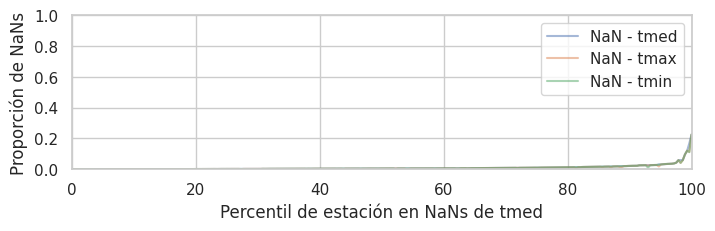

In [60]:
plot_na_distributions(by_id, ['tmed', 'tmax', 'tmin'], fsize=(8, 2), ylim=(0, 1))

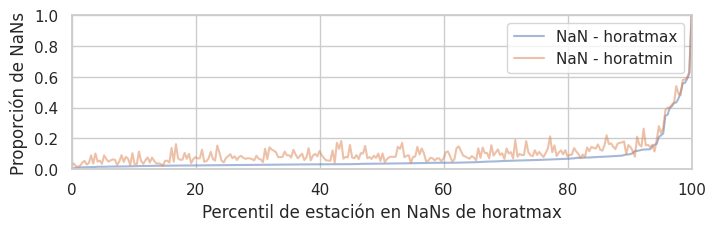

In [61]:
plot_na_distributions(by_id, ['horatmax', 'horatmin'], fsize=(8, 2), ylim=(0, 1))


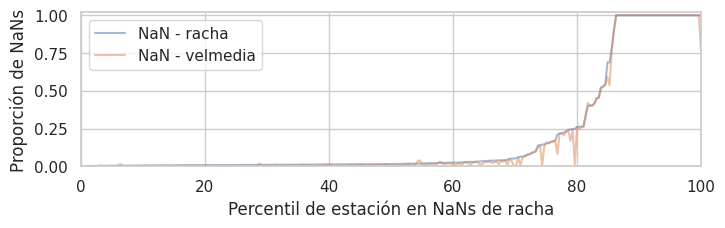

In [62]:
plot_na_distributions(by_id, ['racha', 'velmedia'], fsize=(8, 2))

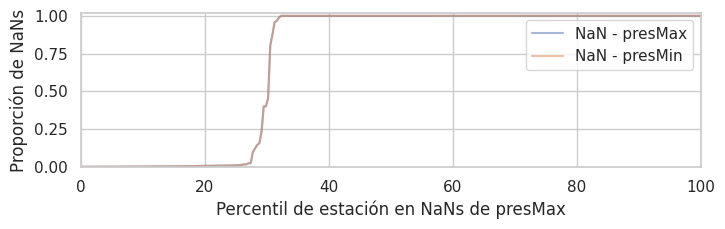

In [63]:
plot_na_distributions(by_id, ['presMax', 'presMin'], fsize=(8, 2))

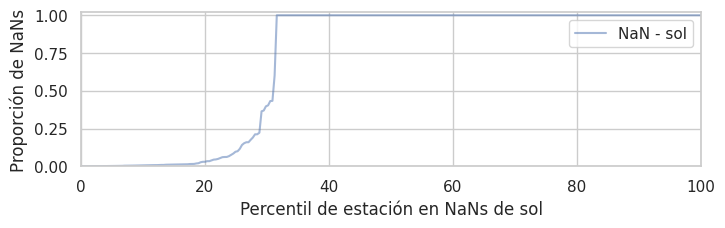

In [64]:
plot_na_distributions(by_id, ['sol'], fsize=(8, 2))

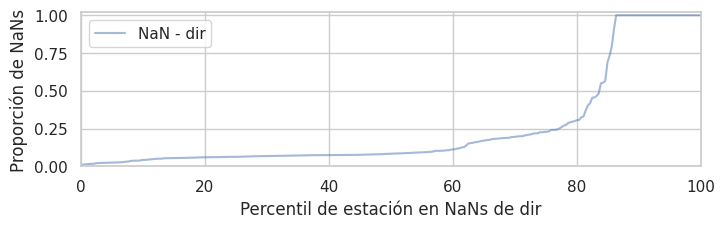

In [65]:
plot_na_distributions(by_id, ['dir'], fsize=(8, 2))

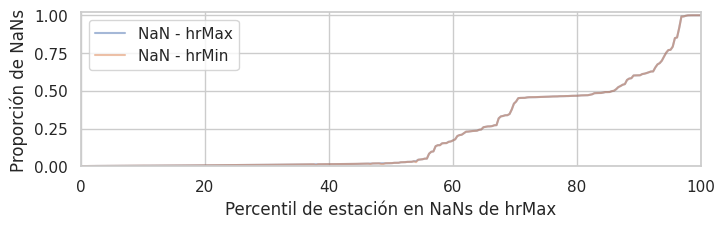

In [66]:
plot_na_distributions(by_id, ['hrMax', 'hrMin'], fsize=(8, 2))

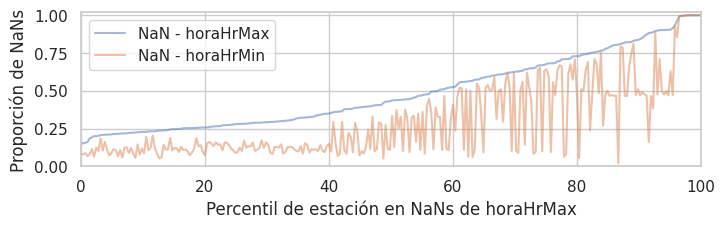

In [67]:
plot_na_distributions(by_id, ['horaHrMax', 'horaHrMin'], fsize=(8, 2))

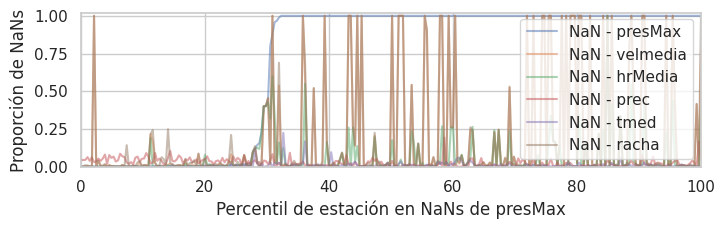

In [68]:
plot_na_distributions(by_id, ['presMax', 'velmedia', 'hrMedia', 'prec', 'tmed', 'racha'], fsize=(8, 2))

In [69]:
from eda_nan import plot_na_distributions_interactive

plot_na_distributions_interactive(by_id, ['presMax', 'presMin', 'velmedia', 'racha', 'hrMedia', 'prec', 'tmed', 'tmin', 'tmax'], fsize=(20, 8))

In [70]:
by_id.shape[0]

286

In [71]:
vars=['tmed', 'tmax', 'tmin', 'horatmax', 'horatmin', 'velmedia', 'racha', 'horaracha', 'dir', 'hrMedia', 'hrMax', 'hrMin', 'horaHrMax', 'horaHrMin', 'prec', 'sol', 'presMax', 'presMin', 'horaPresMax', 'horaPresMin']

((((by_id[vars] == 1).sum() / by_id.shape[0]) * 100)).sort_values(ascending=False).reset_index(name='porcentaje')

,index,porcentaje
0,sol,68.531469
1,presMin,67.132867
2,presMax,67.132867
3,horaPresMax,67.132867
4,horaPresMin,67.132867
5,horaracha,13.986014
6,dir,13.986014
7,racha,13.986014
8,velmedia,13.636364
9,horaHrMax,2.097902


In [72]:
(((by_id[vars].sum() / by_id.shape[0]) * 100).sort_values(ascending=False)).reset_index(name='porcentaje')

,index,porcentaje
0,horaPresMax,76.471238
1,horaPresMin,73.419047
2,sol,70.654456
3,presMin,70.253942
4,presMax,70.253062
5,horaHrMax,48.842207
6,horaHrMin,29.784270
7,horaracha,24.942770
8,dir,24.923498
9,hrMax,21.723423


## 5.2 Distribución de NaNs a lo largo de los años

### 5.2.1. Día del año

In [73]:
from eda_nan import plot_nan_evolution, plot_nan_evolution_day_of_year, plot_nan_evolution_compare

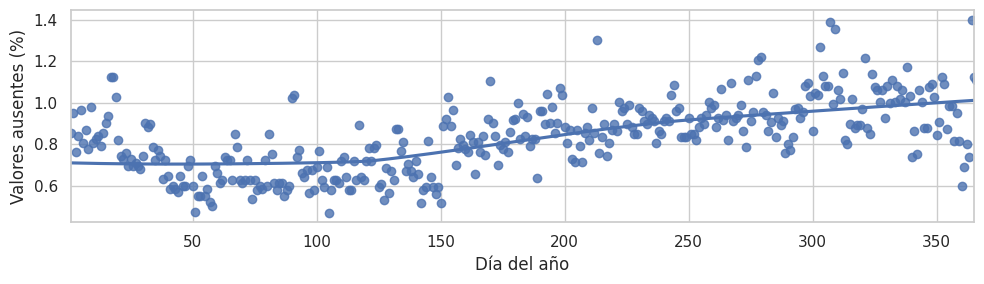

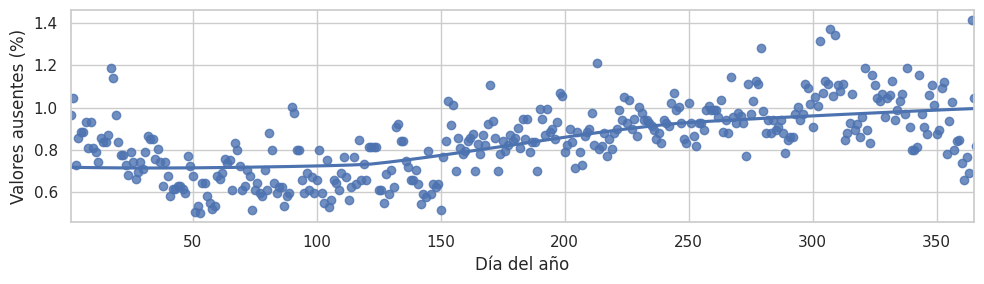

In [74]:
plot_nan_evolution_day_of_year(selected_df, "tmax", title=False, fsize=(10, 3))
plot_nan_evolution_day_of_year(selected_df, "tmin", title=False, fsize=(10, 3))

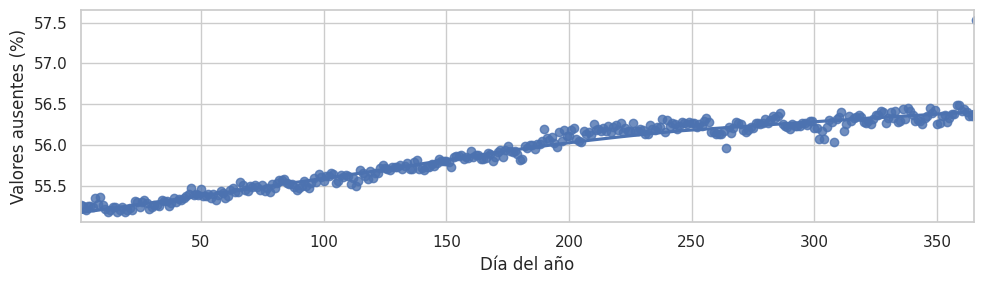

In [75]:
plot_nan_evolution_day_of_year(selected_df, "presMax", title=False, fsize=(10, 3))

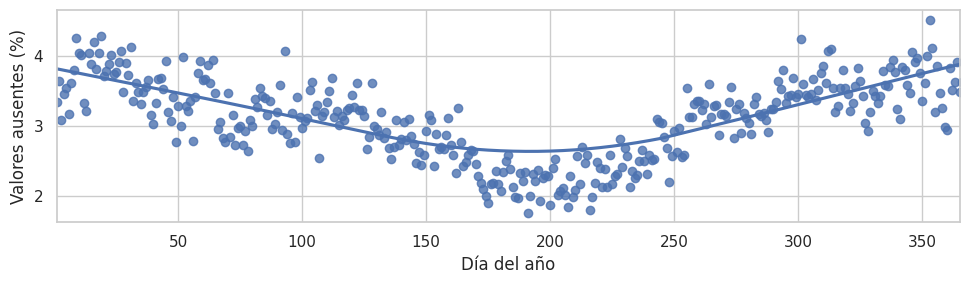

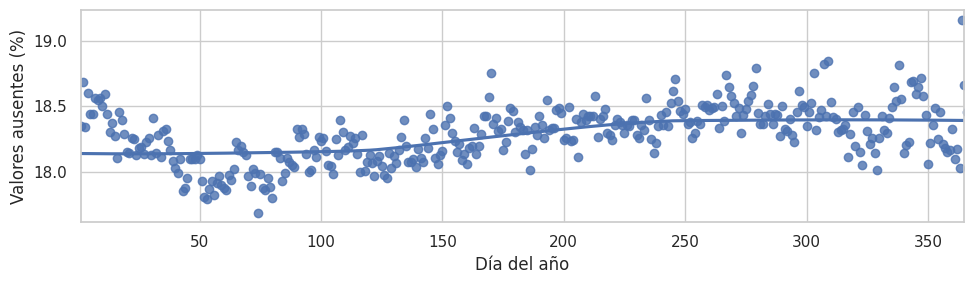

In [76]:
plot_nan_evolution_day_of_year(selected_df, "prec", title=False, fsize=(10, 3))
plot_nan_evolution_day_of_year(selected_df, "racha", title=False, fsize=(10, 3))

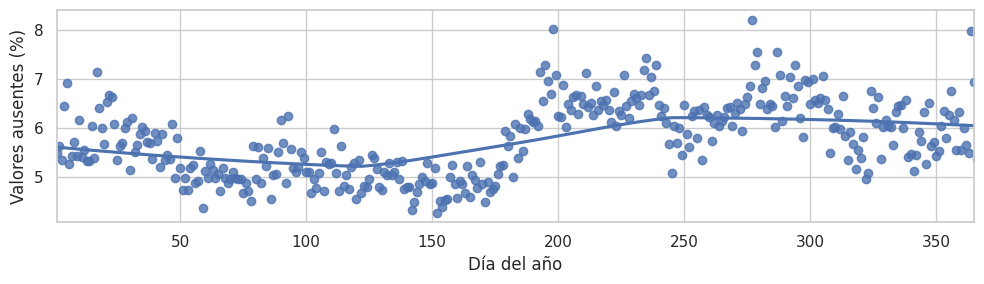

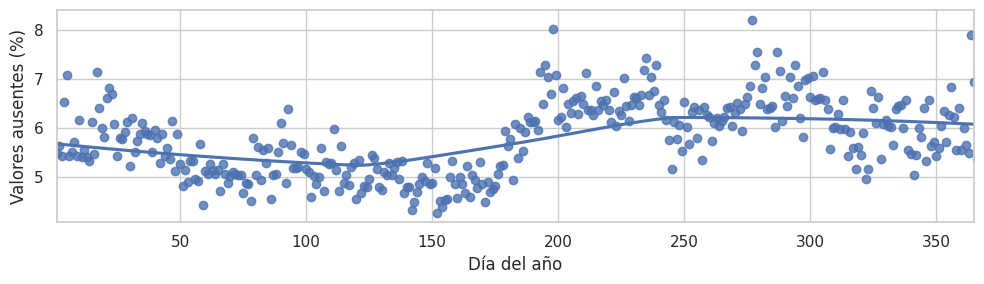

In [77]:
plot_nan_evolution_day_of_year(df_clm, "tmax", title=False, fsize=(10, 3))
plot_nan_evolution_day_of_year(df_clm, "tmin", title=False, fsize=(10, 3))

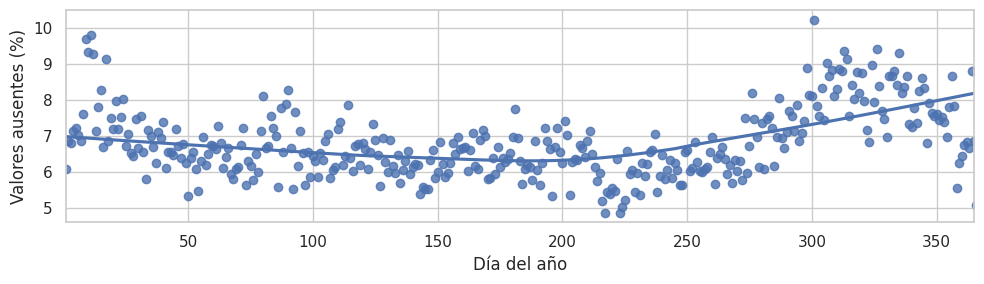

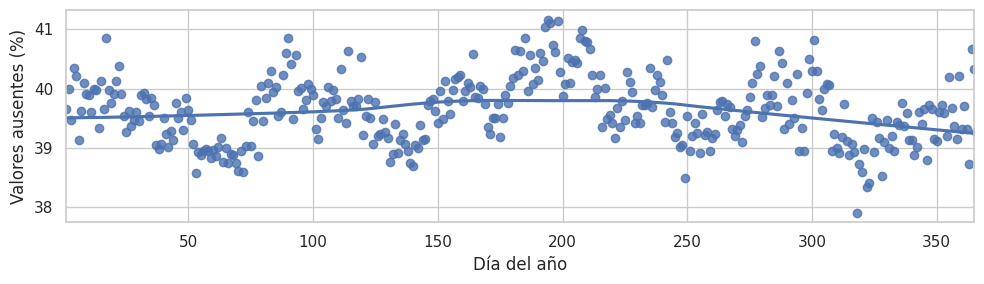

In [78]:
plot_nan_evolution_day_of_year(df_clm, "prec", title=False, fsize=(10, 3))
plot_nan_evolution_day_of_year(df_clm, "racha", title=False, fsize=(10, 3))

### 5.2.2. Año

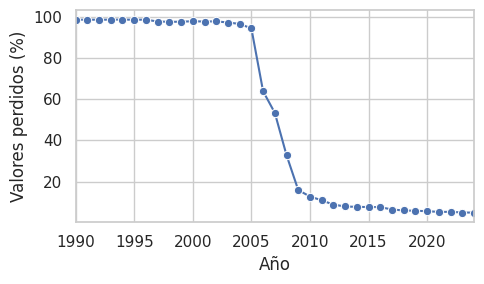

In [79]:
plot_nan_evolution(selected_df, 'hrMax', xlim=(1990, 2024), title=False, fsize=(5, 3))

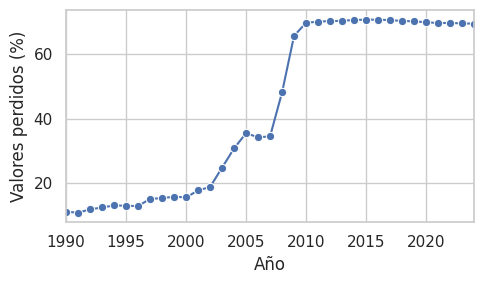

In [80]:
plot_nan_evolution(selected_df, 'presMax', xlim=(1990, 2024), title=False, fsize=(5, 3))

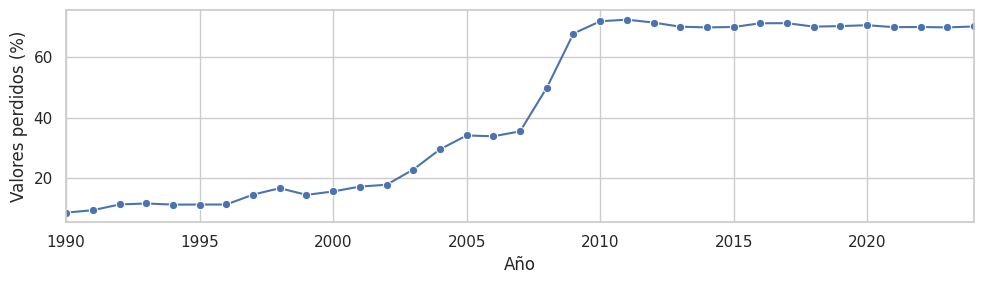

In [81]:
plot_nan_evolution(selected_df, 'sol', xlim=(1990, 2024), title=False, fsize=(10, 3))

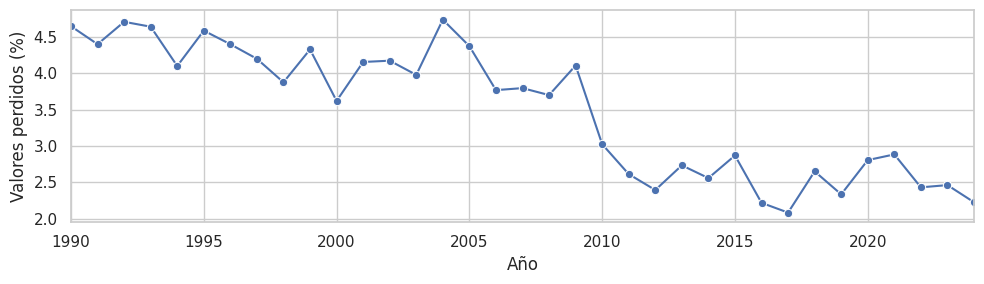

In [82]:
plot_nan_evolution(selected_df, 'prec', xlim=(1990, 2024), title=False, fsize=(10, 3))

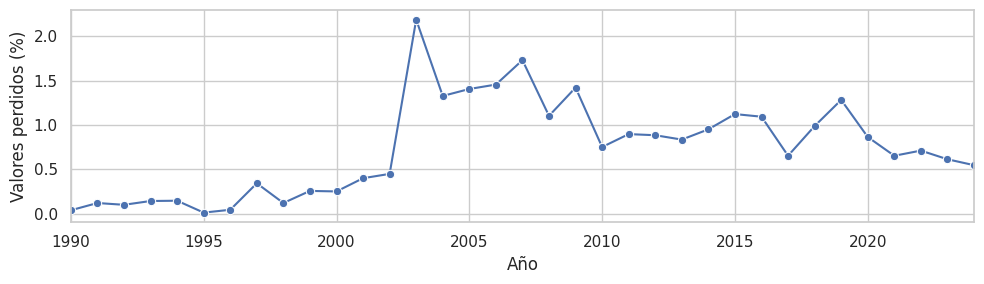

In [83]:
plot_nan_evolution(selected_df, 'tmax', xlim=(1990, 2024), title=False, fsize=(10, 3))

In [84]:
prev_stations = selected_stations[selected_stations['fecha_min'] < '2002-01-01']
post_stations = selected_stations[selected_stations['fecha_min'] >= '2002-01-01']

In [85]:
selected_prev = selected_df[selected_df['indicativo'].isin(prev_stations['indicativo'].unique())]
selected_post = selected_df[selected_df['indicativo'].isin(post_stations['indicativo'].unique())]

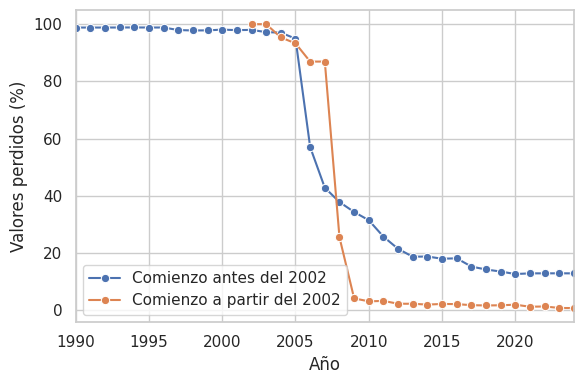

In [86]:
plot_nan_evolution_compare(
    selected_prev,
    selected_post,
    var='hrMax',
    labels=('Comienzo antes del 2002', 'Comienzo a partir del 2002'),
    figsize=(6, 4),
    title=False
    # xlim=(2006, 2024)
)

# plot_nan_evolution_compare(
#     selected_prev,
#     selected_post,
#     var='hrMin',
#     labels=('Comienzo antes del 2002', 'Comienzo a partir del 2002'),
#     figsize=(10, 3),
#     # xlim=(2010, 2024),
#     # ylim=(10, 30),
#     title=False
# )

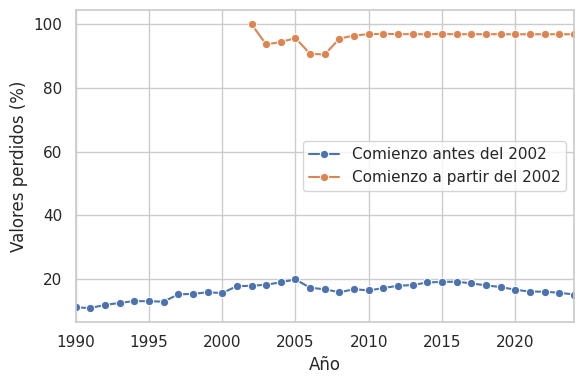

In [87]:
plot_nan_evolution_compare(
    selected_prev,
    selected_post,
    var='presMax',
    labels=('Comienzo antes del 2002', 'Comienzo a partir del 2002'),
    figsize=(6, 4),
    title=False
)

# plot_nan_evolution_compare(
#     selected_prev,
#     selected_post,
#     var='presMin',
#     labels=('Comienzo antes del 2002', 'Comienzo a partir del 2002'),
#     figsize=(10, 3),
#     title=False
# )

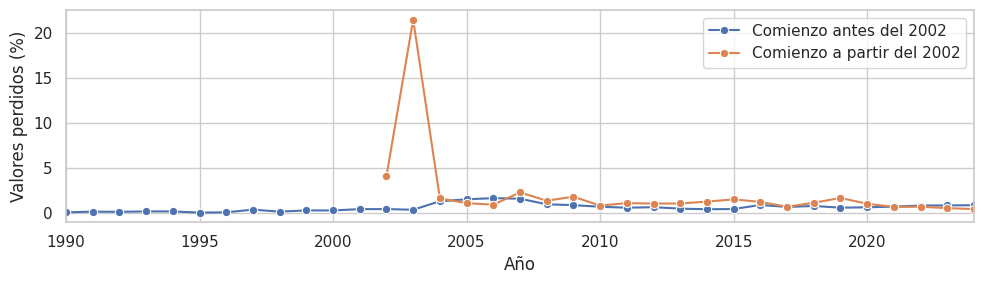

In [88]:
plot_nan_evolution_compare(
    selected_prev,
    selected_post,
    var='tmax',
    labels=('Comienzo antes del 2002', 'Comienzo a partir del 2002'),
    figsize=(10, 3),
    title=False
)

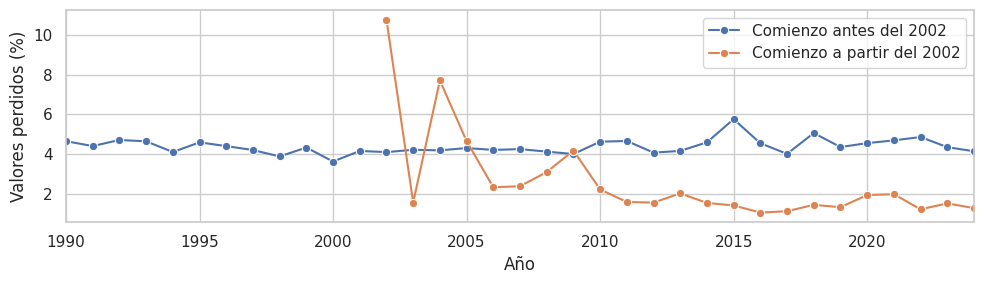

In [89]:
plot_nan_evolution_compare(
    selected_prev,
    selected_post,
    var='prec',
    labels=('Comienzo antes del 2002', 'Comienzo a partir del 2002'),
    figsize=(10, 3),
    title=False
)

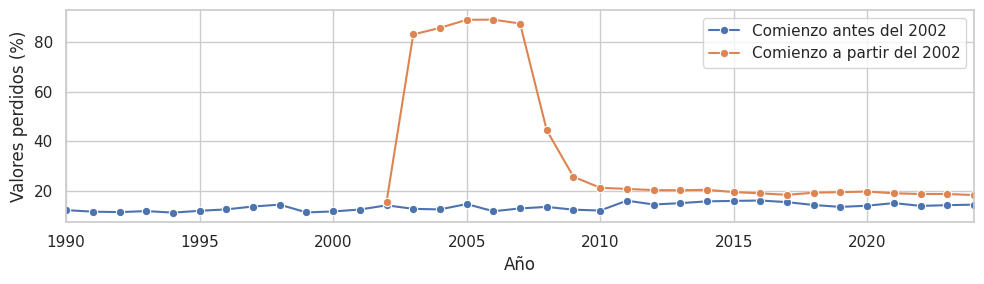

In [90]:
plot_nan_evolution_compare(
    selected_prev,
    selected_post,
    var='racha',
    labels=('Comienzo antes del 2002', 'Comienzo a partir del 2002'),
    figsize=(10, 3),
    # xlim=(2010, 2024),
    # ylim=(10, 30),
    title=False
)

In [91]:
threshold = 0.20

selected_by_id = by_id.loc[
    (by_id['tmed'] <= threshold)
    & (by_id['tmin'] <= threshold)
    & (by_id['tmax'] <= threshold)
    & (by_id['velmedia'] <= threshold)
    & (by_id['racha'] <= threshold)
    # & (by_id['dir'] <= threshold)
    & (by_id['hrMedia'] <= threshold)
    # & (by_id['hrMax'] <= threshold) # REDUCEN DEMASIADO EL DATASET
    # & (by_id['hrMin'] <= threshold) # REDUCEN DEMASIADO EL DATASET
    & (by_id['prec'] <= threshold)
    & (by_id['presMin'] <= threshold)
    & (by_id['presMax'] <= threshold)
    # & (by_id['sol'] <= threshold)
    & (by_id['altitud'] <= 750)
].reset_index(drop=True)
selected_by_id.shape[0]

66

In [92]:
selected_by_id.head()

,indicativo,tmed,tmax,tmin,horatmax,horatmin,horatmaxVarias,horatminVarias,velmedia,racha,horaracha,dir,hrMedia,hrMax,hrMin,horaHrMax,horaHrMin,horaHrMaxVarias,horaHrMinVarias,prec,sol,presMax,presMin,horaPresMax,horaPresMin,horaPresMaxVarias,horaPresMinVarias,dia,n_dias_teoricos,nombre,provincia,fecha_min,fecha_max,altitud,latitud,longitud
0,0016A,0.012933,0.012698,0.012933,0.040445,0.051575,0.0,0.0,0.008857,0.019047,0.236949,0.225427,0.002665,0.457282,0.457282,0.802085,0.466688,0.0,0.0,0.039113,0.013011,0.003214,0.003057,0.401552,0.024769,0.0,0.0,0.0,20089.0,REUS AEROPUERTO,TARRAGONA,1970-01-01,2024-12-31,71,41.145000,1.163611
1,0076,0.004302,0.004302,0.004224,0.064847,0.085576,0.0,0.0,0.007431,0.052566,0.302331,0.241004,0.079787,0.457134,0.457134,0.819462,0.464565,0.0,0.0,0.049437,0.038955,0.005945,0.006023,0.418179,0.071105,0.0,0.0,0.0,20089.0,BARCELONA AEROPUERTO,BARCELONA,1970-01-01,2024-12-31,4,41.292778,2.070000
2,0200E,0.000000,0.000000,0.000000,0.062813,0.137125,0.0,0.0,0.005788,0.028708,0.059840,0.047090,0.001330,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.067193,0.011499,0.001173,0.001173,0.122575,0.192428,0.0,0.0,0.0,20089.0,"BARCELONA, FABRA",BARCELONA,1970-01-01,2024-12-31,408,41.418333,2.124167
3,0367,0.009099,0.008861,0.009020,0.023340,0.043437,0.0,0.0,0.009336,0.033151,0.253501,0.240051,0.008149,0.466809,0.466809,0.914313,0.471556,0.0,0.0,0.058707,0.029512,0.010365,0.010365,0.470844,0.083867,0.0,0.0,0.0,18993.0,GIRONA AEROPUERTO,GIRONA,1973-01-01,2024-12-31,143,41.911389,2.763056
4,1014,0.000000,0.000000,0.000000,0.038407,0.086514,0.0,0.0,0.000626,0.003285,0.100829,0.045447,0.000000,0.571730,0.571730,0.710732,0.608964,0.0,0.0,0.038329,0.000156,0.000078,0.000078,0.044196,0.045056,0.0,0.0,0.0,20089.0,"HONDARRIBIA, MALKARROA",GIPUZKOA,1970-01-01,2024-12-31,4,43.356944,-1.792222


In [93]:
plot_na_distributions_interactive(selected_by_id, ['presMax', 'presMin', 'velmedia', 'racha', 'hrMedia', 'prec', 'tmed', 'tmin', 'tmax'], fsize=(15, 7))

In [94]:
final_selected_df = df.loc[df['indicativo'].isin(selected_by_id['indicativo'])]
final_selected_df = final_selected_df[final_selected_df['anio'] >= 1990]
print(f'Se han seleccionado un finalmente un total de {len(final_selected_df)} registros de {len(selected_by_id)} estaciones')

Se han seleccionado un finalmente un total de 799338 registros de 66 estaciones


In [95]:
fig = px.scatter_map(selected_by_id, lat='latitud', lon='longitud')

min_lat, max_lat = selected_by_id['latitud'].min(), selected_by_id['latitud'].max()
min_lon, max_lon = selected_by_id['longitud'].min(), selected_by_id['longitud'].max()

centro_lat = (min_lat + max_lat) / 2
centro_lon = (min_lon + max_lon) / 2

fig.update_traces(marker={"size": 5})

fig.update_layout(
    map_style='carto-positron-nolabels',
    map_center={"lat": centro_lat, "lon": centro_lon},
    map_zoom=4.6,
    margin={'l': 5, 'r': 5, 't': 5, 'b': 5}, 
    width=1400, 
    height=800
)

fig.show()

# 6. Conclusión

Para este punto, se decidió:
* Suplementar datos de AEMET con datos de ERA5.
* Reducir longitud de serie temporal de 1970-2024 a 2010-2024
* Reducir datos a Castilla-La Mancha

Más adelante se descubrió que realizando una selección de estaciones meteorológicas en base a los criterios explorados en el punto 3 del archivo se consigue una mayor cantidad de datos con mayor calidad.

## 6.1. Estandarización de la presión atmosférica.

La presión es algo muy específico para la localización y altitud de cada estación meteorológica, se cambiará por presión ajustada al nivel del mar, para que todos los registros compartan un marco de referencia común.

La fórmula dada por el WMO para la reducción de presión a nivel del mar en la [Guía de Instrumentos y Métodos de Información](https://library.wmo.int/idurl/4/41613), Volumen I, Capítulo 3.7.2 es la siguiente:


$$
p_0 = p_s \cdot \exp \left[ \frac{g_n \cdot H_p}{R \cdot \left( T_s + \frac{a \cdot H_p}{2} + e_s \cdot C_h \right)} \right]
$$
Con las variables:

* p0​: Presión a Nivel Medio del Mar (hPa)

* ps​: Presión en Estación (hPa)

* Hp​: Elevación en Estación (m / metro geopotencial)

* Ts​: Temperatura en Estación en Kelvin (ºC​+273.15)

* es​: Presión de Vapor en Estación (hPa)

* gn​: Gravedad Estándar (9.80665m/s^2)

* R: Constante de Gases del aire seco (287.05J kg−1K−1)

* a: Tasa Estándar de Decrecimiento de Temperatura con Altura (0.0065K gpm−1)

* Ch​: Coeficiente de Presión de Vapor (0.12K hPa−1)

Con los datos disponibles mediante una serie de ecuaciones adicionales, se podrán convertir las medidas de presión obtenidas por las estaciones meteorológicas en un nivel estándar de presión.

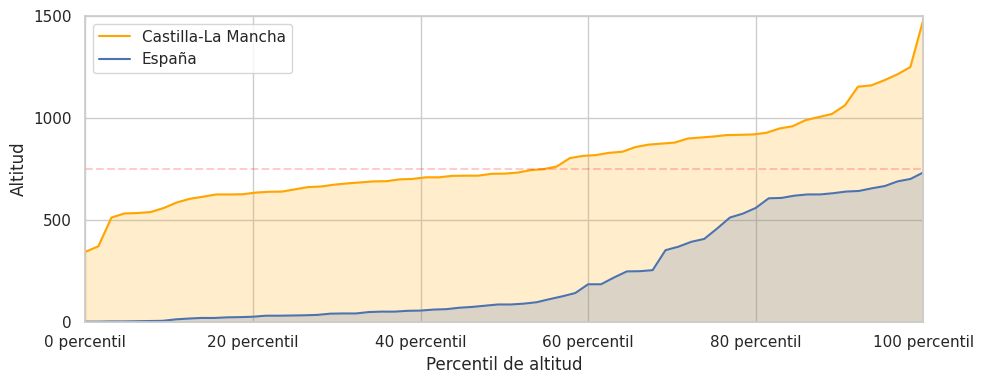

69728

In [96]:
plt.figure(figsize=(10, 4))

s_sub = s_df_clm.copy()
s_sub = s_sub.loc[
    (s_sub['altitud'].notna()),
    ['indicativo', 'altitud']
].sort_values(by='altitud').reset_index()
s_sub['percentile'] = np.linspace(0, 100, len(s_sub))

sns.lineplot(data=s_sub, x='percentile', y='altitud', color='orange', label='Castilla-La Mancha')
plt.fill_between(s_sub['percentile'], s_sub['altitud'], alpha=0.2, color='orange')


s_sub = s_df_selected.copy()
s_sub = s_sub.loc[
    (s_sub['altitud'].notna()),
    ['indicativo', 'altitud']
].sort_values(by='altitud').reset_index()
s_sub['percentile'] = np.linspace(0, 100, len(s_sub))

sns.lineplot(data=s_sub, x='percentile', y='altitud',  label='España')

plt.fill_between(s_sub['percentile'], s_sub['altitud'], alpha=0.2)

# plt.title('Altitudes de las estaciones por percentil de altitud')
plt.xlabel('Percentil de altitud')
plt.ylabel('Altitud')

x_max = s_sub.shape[0]-1
x_lines = [0, 20, 40, 60, 80, 100]
x_label = ['0 percentil', '20 percentil', '40 percentil', '60 percentil', '80 percentil', '100 percentil']

plt.axhline(y=750, linestyle='--', color='red', alpha=0.2)
plt.xticks(x_lines, x_label)  
plt.yticks(y_lines, y_label)
plt.xlim(0, 100)
plt.ylim(0, 1500)
plt.tight_layout()
plt.show()

del s_sub
gc.collect()

In [97]:
s_df_clm["altitud"].max()

np.int64(1485)

## 6.2. Castilla-La Mancha

Por la poca cantidad de registros, no es factible hacer selección de estaciones de Castilla-La Mancha, resultando del proceso únicamente dos. Es por ello que se ha decidido que a la hora de elaborar un dataset específico de Castilla-La Mancha se usarán datos suplementarios para rellenar tanto los registros como los valores perdidos.